# Sven against the full optimizer suite --- the four MLP scans side by side

Fourteen or fifteen optimizers, four problems, one set of conventions.  The per-scan
notebooks (`toy_1d_analysis`, `polynomial_analysis`, `mnist_analysis_labelRegression`,
`mnist_analysis`) go through each scan in detail; this one asks the cross-scan questions:
**does a method's standing survive a change of problem, and does it survive a change of
axis** (steps, examples, time)?

Everything is a **confirmation-seed** number --- `{scan}_confirm/`, 5 fresh model seeds
(and 3 data seeds on toy and polynomial) of the configuration `bench/best_configs.json`
selected on the tuning grid by seed-mean final **validation** loss under the binding rule
(eligible -> fewest diverged -> seed mean).  Test loss and accuracy are **outcomes**, never
selectors.  Diverged = failed: left out of every mean, always counted, `finished /
attempted` on every table.  A `±` or a band is 1 std (ddof = 1) over seeds.

The numbers come from `analysis/headline.py`; this notebook arranges them through
`analysis/headline_figs.py` and derives none of them itself.  CIFAR-10 and nanoGPT are
headline scans too, but they belong to `cifar_analysis` / `nanogpt_analysis` /
`gpt2_analysis`; the cross-scan ranking in section 2 covers all seven so that the four MLP
scans are not read as the whole campaign.

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '.')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import budget
import headline as hl
import headline_figs as hf
import paired
import scan_analysis as sa
import style
from style import set_style, DATASET_TITLES

set_style()
pd.set_option('display.width', 240)
pd.set_option('display.max_columns', 90)

In [2]:
METRIC   = 'final_val_loss'
PLOT_DIR = Path('plots_v2/baselines')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# The four MLP scans, in the order the paper reports them.
SCANS = ['toy_1d_scan', 'polynomial_scan', 'mnist_scan_labelRegression', 'mnist_scan_ce']

scans, conf, eff, div, ttt, bt, gpus = {}, {}, {}, {}, {}, {}, {}
for name in SCANS:
    hf.provisional_banner(name)
    scans[name] = sa.load_scan(name, hl.scan_title(name), PLOT_DIR, metric=METRIC)
    conf[name] = hl.confirmation_table(name)
    eff[name] = hl.efficiency_table(name)
    ttt[name] = hl.time_to_target_table(name)
    bt[name] = hl.budget_table(name)
    div[name] = hf.divergence_by_method(scans[name].df)
    # every rank and paired difference below comes out of the confirmation pass, so
    # whether that pass ran on ONE device type is part of reading them
    gpus[name] = hf.gpu_homogeneity_line(name, 'confirm')
print(f'\nloaded {len(scans)} scans; plots -> {PLOT_DIR.resolve()} (PDF + PNG)')
print('confirmation-pass device homogeneity: '
      + ', '.join(f'{hl.scan_title(n)} '
                  + ('one type' if gpus[n].attrs['homogeneous'] else 'MIXED')
                  for n in SCANS))

[fresh] toy_1d_scan: no runs in flight; every table below is final with respect to the selection written 2026-09-20T22:06:52-0400
Loaded 1770 runs from ../experiment_results/_cache/toy_1d_scan.slim.pkl (slim cache)
toy_1d_scan: 1770 runs  |  B=32, 20 epochs, 5 seeds  |  Sven k=[1, 2, 4, 8, 16, 32] rtol=[1e-06, 1e-05, 0.0001, 0.001, 0.01]


  289 diverged run(s), excluded from seed means: {'SVD': 194, 'LBFGS': 52, 'KFAC': 19, 'HIG': 11, 'SGD': 5, 'SGDm': 5, 'SOAP': 3}
  manifest: 1770 of 1770 intended runs present, 0 with no record
Loaded 1770 runs from ../experiment_results/_cache/toy_1d_scan.slim.pkl (slim cache)
Loaded 225 runs from ../experiment_results/_cache/toy_1d_scan_confirm.slim.pkl (slim cache)


Loaded 75 runs from ../experiment_results/_cache/toy_1d_scan_timing.slim.pkl (slim cache)


  GPU: all 225 confirm runs on NVIDIA A100-SXM4-40GB MIG 3g.20gb -- one device type, so a rank or a paired difference here compares like with like
[fresh] polynomial_scan: no runs in flight; every table below is final with respect to the selection written 2026-09-20T22:06:52-0400
Loaded 1630 runs from ../experiment_results/_cache/polynomial_scan.slim.pkl (slim cache)


polynomial_scan: 1630 runs  |  B=32, 20 epochs, 5 seeds  |  Sven k=[1, 2, 4, 8, 16, 32] rtol=[1e-05, 0.0001, 0.001, 0.01, 0.03, 0.1]
  260 diverged run(s), excluded from seed means: {'LBFGS': 204, 'KFAC': 21, 'SGDm': 12, 'SGD': 8, 'SOAP': 4, 'SVD': 4, 'HIG': 3, 'RMSprop': 3, 'MuonW': 1}
  manifest: 1630 of 1630 intended runs present, 0 with no record
Loaded 1630 runs from ../experiment_results/_cache/polynomial_scan.slim.pkl (slim cache)
Loaded 225 runs from ../experiment_results/_cache/polynomial_scan_confirm.slim.pkl (slim cache)


...

Loaded 70 runs from ../experiment_results/_cache/mnist_scan_labelRegression_timing.slim.pkl (slim cache)


  GPU: the confirm pass is NOT homogeneous -- 45 run(s) on NVIDIA A100-SXM4-40GB MIG 3g.20gb, 25 run(s) on NVIDIA A100-SXM4-80GB.  A comparison BETWEEN methods that ran on different device types carries the cross-GPU deviation of section 6 on top of the seed spread:
    Adam                 5x NVIDIA A100-SXM4-40GB MIG 3g.20gb
    AdamW                5x NVIDIA A100-SXM4-80GB
    HIG                  5x NVIDIA A100-SXM4-40GB MIG 3g.20gb
    JD (UPGrad)          5x NVIDIA A100-SXM4-40GB MIG 3g.20gb
    Muon                 5x NVIDIA A100-SXM4-80GB
    MuonW                5x NVIDIA A100-SXM4-40GB MIG 3g.20gb
    Polyak SGD           5x NVIDIA A100-SXM4-40GB MIG 3g.20gb
    RMSprop              5x NVIDIA A100-SXM4-80GB
    SGD                  5x NVIDIA A100-SXM4-80GB
    SGD + momentum       5x NVIDIA A100-SXM4-40GB MIG 3g.20gb
    SOAP                 5x NVIDIA A100-SXM4-40GB MIG 3g.20gb
    Shampoo              5x NVIDIA A100-SXM4-40GB MIG 3g.20gb
    Stochastic L-BFGS    5x NVIDIA A1

mnist_scan_ce: 1610 runs  |  B=64, 20 epochs, 5 seeds  |  Sven k=[1, 2, 4, 8, 16, 32, 48, 64] rtol=[0.0001, 0.001, 0.01, 0.1, 0.3]
  131 diverged run(s), excluded from seed means: {'LBFGS': 70, 'KFAC': 40, 'SOAP': 9, 'SGDm': 5, 'MuonW': 3, 'SGD': 3, 'RMSprop': 1}
  manifest: 1610 of 1610 intended runs present, 0 with no record
Loaded 1610 runs from ../experiment_results/_cache/mnist_scan_ce.slim.pkl (slim cache)
Loaded 70 runs from ../experiment_results/_cache/mnist_scan_ce_confirm.slim.pkl (slim cache)


Loaded 70 runs from ../experiment_results/_cache/mnist_scan_ce_timing.slim.pkl (slim cache)


  GPU: the confirm pass is NOT homogeneous -- 38 run(s) on NVIDIA A100-SXM4-40GB MIG 3g.20gb, 32 run(s) on NVIDIA A100-SXM4-80GB.  A comparison BETWEEN methods that ran on different device types carries the cross-GPU deviation of section 6 on top of the seed spread:
    Adam                 5x NVIDIA A100-SXM4-40GB MIG 3g.20gb
    AdamW                5x NVIDIA A100-SXM4-80GB
    HIG                  5x NVIDIA A100-SXM4-40GB MIG 3g.20gb
    JD (UPGrad)          4x NVIDIA A100-SXM4-80GB, 1x NVIDIA A100-SXM4-40GB MIG 3g.20gb
    Muon                 5x NVIDIA A100-SXM4-40GB MIG 3g.20gb
    MuonW                5x NVIDIA A100-SXM4-40GB MIG 3g.20gb
    Polyak SGD           5x NVIDIA A100-SXM4-80GB
    RMSprop              5x NVIDIA A100-SXM4-40GB MIG 3g.20gb
    SGD                  5x NVIDIA A100-SXM4-80GB
    SGD + momentum       5x NVIDIA A100-SXM4-40GB MIG 3g.20gb
    SOAP                 4x NVIDIA A100-SXM4-80GB, 1x NVIDIA A100-SXM4-40GB MIG 3g.20gb
    Shampoo              4x NVIDIA 

## 2. Results summary: every method, every scan

The first matrix is the headline number itself --- the confirmation-seed final validation
loss of each method's selected configuration --- and the second is its **rank** within the
scan, which is the only thing comparable across four problems whose losses differ by seven
orders of magnitude.  `finished / attempted` is the third matrix: a blank cell is a method
with no selected configuration at all (K-FAC dies deterministically on both MNIST scans ---
`torch.linalg.eigh` fails on the rank-deficient Kronecker-factored Fisher --- so it has no
eligible configuration there and those scans have 14 methods, not 15).

In [3]:
val_m = hf.scan_matrix(conf, 'val_conf')
hl.print_table(val_m.reset_index(), 'Final VALIDATION loss on the confirmation seeds '
                                    '(the quantity every selection was made on)')

acc_m = hf.scan_matrix(conf, 'acc_conf')
if acc_m.notna().any().any():
    hl.print_table(acc_m.dropna(how='all', axis=1).reset_index(),
                   'Final TEST accuracy (an OUTCOME, never selected on)')

counts = {s: t.assign(fa=[f'{int(a)}/{int(b)}' for a, b in zip(t['fin_conf'], t['att_conf'])])
          for s, t in conf.items()}
hl.print_table(hf.scan_matrix(counts, 'fa').reset_index(),
               'finished / attempted on the confirmation seeds')


### Final VALIDATION loss on the confirmation seeds (the quantity every selection was made on)
| display | Toy 1D | Random Polynomial | MNIST (label reg.) | MNIST (CE) |
|---|---|---|---|---|
| Sven | 5.086e-07 | 0.1388 | 0.05328 | 0.1134 |
| Adam | 3.264e-05 | 0.2377 | 0.05844 | 0.1456 |
| AdamW | 1.735e-05 | 0.2442 | 0.05784 | 0.1368 |
| HIG | 1.775e-09 | 0.08406 | 0.05298 | 0.1119 |
| JD (UPGrad) | 0.0007893 | 0.1635 | 0.05902 | 0.1591 |
| KFAC | 1.802e-05 | 0.2118 |  |  |
| Muon | 2.159e-05 | 0.207 | 0.05473 | 0.1067 |
| MuonW | 1.928e-05 | 0.2313 | 0.04982 | 0.1046 |
| Polyak SGD | 8.792e-05 | 0.1997 | 0.05532 | 0.1471 |
| RMSprop | 0.0002746 | 0.2173 | 0.05989 | 0.153 |
| SGD | 0.001084 | 0.3182 | 0.05524 | 0.1258 |
| SGD + momentum | 6.027e-06 | 0.2805 | 0.05524 | 0.1249 |
| SOAP | 3.372e-06 | 0.1818 | 0.5808 | 0.646 |
| Shampoo | 0.0002956 | 0.6137 | 0.0804 | 0.1317 |
| Stochastic L-BFGS | 0.0002659 | 0.4855 | 0.06127 | 0.1307 |

### Final TEST accuracy (an OUTCOME, never sele

,display,Toy 1D,Random Polynomial,MNIST (label reg.),MNIST (CE)
0,Sven,15/15,15/15,5/5,5/5
1,Adam,15/15,15/15,5/5,5/5
2,AdamW,15/15,15/15,5/5,5/5
3,HIG,15/15,15/15,5/5,5/5
4,JD (UPGrad),15/15,15/15,5/5,5/5
5,KFAC,15/15,15/15,NaN,NaN
6,Muon,15/15,15/15,5/5,5/5
7,MuonW,15/15,15/15,5/5,5/5
8,Polyak SGD,15/15,15/15,5/5,5/5
9,RMSprop,15/15,15/15,5/5,5/5


In [4]:
# Ranks, across ALL SEVEN headline scans -- the four here plus the two CIFAR scans and
# nanoGPT, so this notebook cannot be read as if the MLP scans were the whole campaign.
# The freshness gate for ALL SEVEN headline scans, not just the four loaded above: the
# rank matrix below covers CIFAR and nanoGPT too, and CIFAR-CE is the scan whose rtol
# extension can still move a rank.
fresh = hl.freshness_report()
hl.print_table(fresh, f'Freshness against the selection written '
                      f'{fresh.attrs["selection_generated_at"]}')
for s in fresh.attrs['provisional_scans']:
    print(f'PROVISIONAL: {hl.scan_title(s)} ({s}) still has runs in flight -- every '
          f'number for it below is provisional until tools/select_best.py is re-run and '
          f'this notebook re-executed.')

summary = hl.ranking_summary()
for value, label in (('rank_val', 'confirmation VALIDATION loss'),
                     ('rank_test', 'confirmation TEST loss (outcome)'),
                     ('rank_acc', 'confirmation TEST accuracy (outcome)')):
    mat = hl.rank_matrix(summary, value)
    hl.print_table(mat.reset_index(), f'Rank by {label} (1 = best; Sven first)')

sven = summary[summary['method'] == 'Sven'].set_index('scan')
for scan, r in sven.iterrows():
    bits = [f"{int(r['rank_val'])}/{int(r['n_methods'])} val"]
    if np.isfinite(r['rank_test']):
        bits.append(f"{int(r['rank_test'])}/{int(r['n_methods'])} test loss")
    if np.isfinite(r['rank_acc']):
        bits.append(f"{int(r['rank_acc'])}/{int(r['n_methods'])} test acc")
    print(f"{hl.scan_title(scan):28s} Sven " + ', '.join(bits))


### Freshness against the selection written 2026-09-20T22:06:52-0400
| scan | pass | selection_input | n_records | newest_record | n_after_selection | n_claims_live | provisional |
|---|---|---|---|---|---|---|---|
| toy_1d_scan | scan | True | 1770 | 2026-09-20 04:26:06 | 0 | 0 | False |
| toy_1d_scan | confirm | False | 225 | 2026-09-20 08:18:48 | 0 | 0 | False |
| toy_1d_scan | timing | False | 75 | 2026-09-20 09:08:05 | 0 | 0 | False |
| polynomial_scan | scan | True | 1630 | 2026-09-20 04:10:03 | 0 | 0 | False |
| polynomial_scan | confirm | False | 225 | 2026-09-20 08:33:38 | 0 | 0 | False |
| polynomial_scan | timing | False | 75 | 2026-09-20 09:06:08 | 0 | 0 | False |
| mnist_scan_labelRegression | scan | True | 1360 | 2026-09-19 19:14:25 | 0 | 0 | False |
| mnist_scan_labelRegression | confirm | False | 70 | 2026-09-20 10:32:34 | 0 | 0 | False |
| mnist_scan_labelRegression | timing | False | 70 | 2026-09-20 14:39:44 | 0 | 0 | False |
| mnist_scan_ce | scan | True | 1610 | 20

Loaded 600 runs from ../experiment_results/_cache/cifar10_resnet_scan_labelRegression.slim.pkl (slim cache)
Loaded 55 runs from ../experiment_results/_cache/cifar10_resnet_scan_labelRegression_confirm.slim.pkl (slim cache)
Loaded 785 runs from ../experiment_results/_cache/cifar10_resnet_ce_scan.slim.pkl (slim cache)


Loaded 60 runs from ../experiment_results/_cache/cifar10_resnet_ce_scan_confirm.slim.pkl (slim cache)
Loaded 140 runs from ../experiment_results/_cache/exp_nanogpt_speedrun.slim.pkl (slim cache)
Loaded 25 runs from ../experiment_results/_cache/exp_nanogpt_speedrun_confirm.slim.pkl (slim cache)



### Rank by confirmation VALIDATION loss (1 = best; Sven first)
| title | Sven | Adam | AdamW | HIG | JD (UPGrad) | KFAC | Muon | MuonW | Polyak SGD | RMSprop | SGD | SGD + momentum | SOAP | Shampoo | Stochastic L-BFGS |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| Toy 1D | 2 | 9 | 5 | 1 | 14 | 6 | 8 | 7 | 10 | 12 | 15 | 4 | 3 | 13 | 11 |
| Random Polynomial | 2 | 10 | 11 | 1 | 3 | 7 | 6 | 9 | 5 | 8 | 13 | 12 | 4 | 15 | 14 |
| MNIST (label reg.) | 3 | 9 | 8 | 2 | 10 |  | 4 | 1 | 7 | 11 | 5 | 6 | 14 | 13 | 12 |
| MNIST (CE) | 4 | 10 | 9 | 3 | 13 |  | 2 | 1 | 11 | 12 | 6 | 5 | 14 | 8 | 7 |
| CIFAR-10 (label reg.) | 9 | 5 | 4 |  |  |  | 3 | 1 | 8 | 6 | 11 | 10 | 2 |  | 7 |
| CIFAR-10 (CE) | 9 | 7 | 4 |  |  |  | 5 | 1 | 11 | 8 | 3 | 10 | 6 |  | 2 |
| nanoGPT (tiny-shakespeare) | 2 |  | 1 |  |  |  | 4 | 3 |  |  |  |  | 5 |  |  |

### Rank by confirmation TEST loss (outcome) (1 = best; Sven first)
| title | Sven | Adam | AdamW | HIG | JD (UPGrad) | KFAC | Muon | MuonW

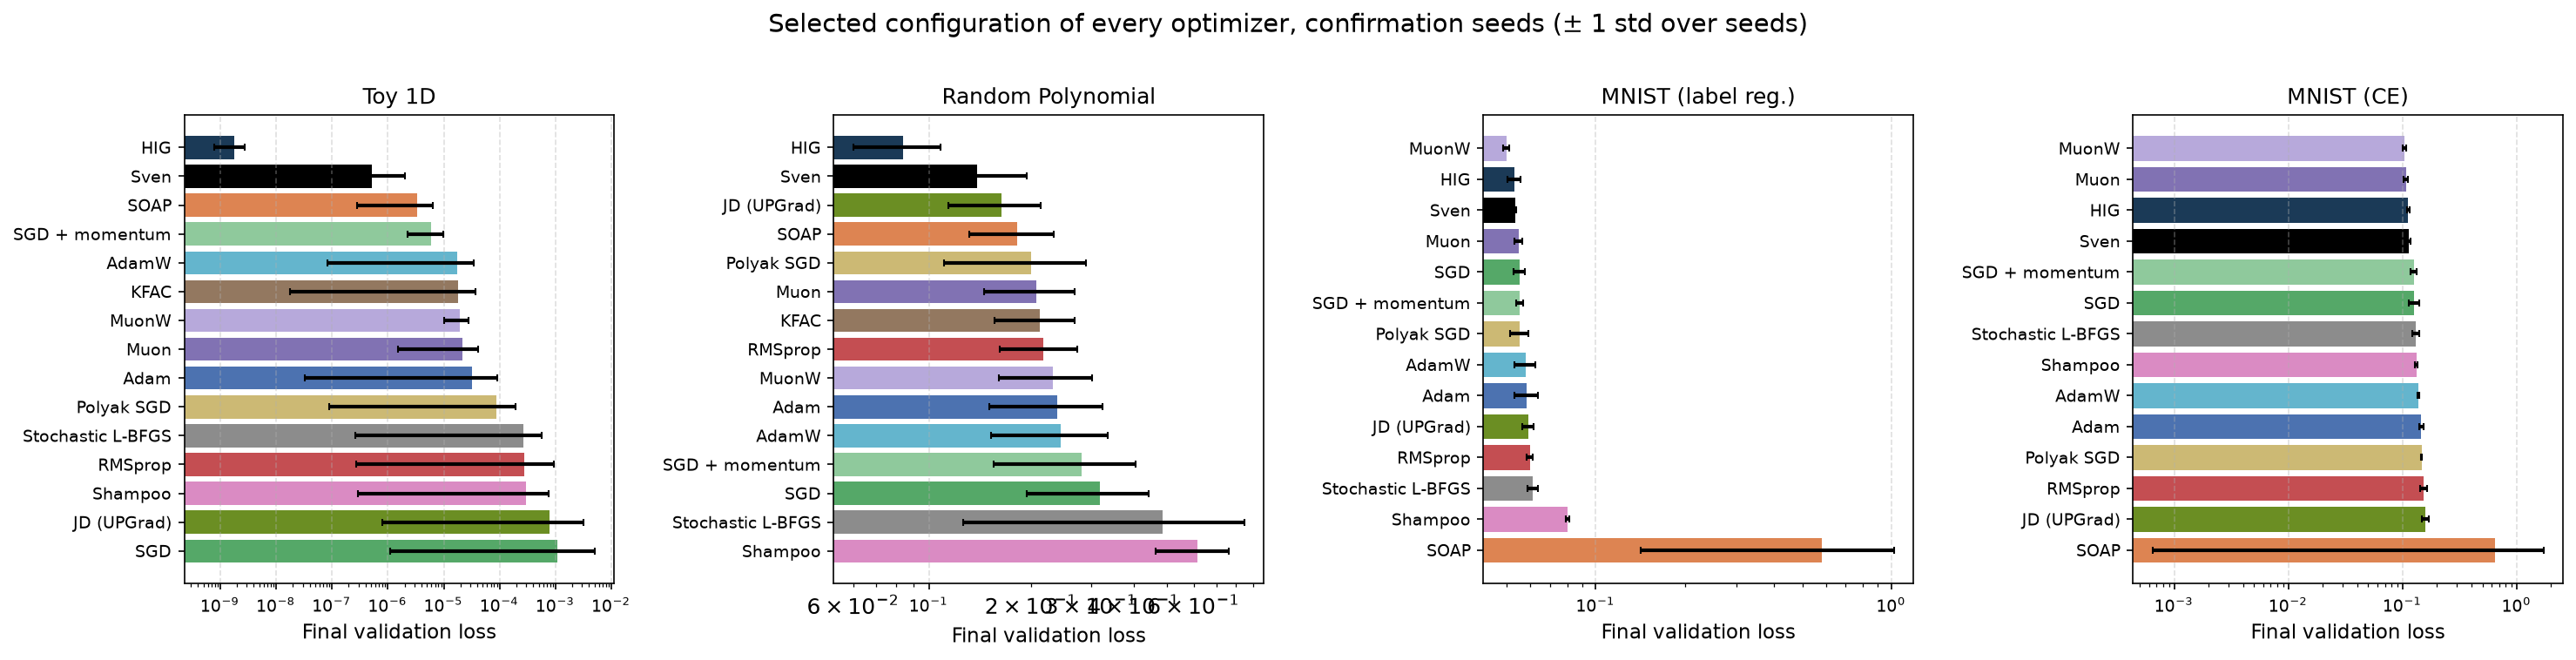

In [5]:
fig, axes = plt.subplots(1, len(SCANS), figsize=(5.0 * len(SCANS), 5.2), squeeze=False)
for ax, name in zip(axes[0], SCANS):
    d = conf[name].sort_values('val_conf', kind='mergesort')
    mean = d['val_conf'].to_numpy(float)
    std = np.nan_to_num(d['val_conf_std'].to_numpy(float))
    y = np.arange(len(d))
    ax.barh(y, mean, xerr=[np.minimum(std, mean * 0.999), std], capsize=2,
            color=[style.method_color(m) for m in d['method']])
    ax.set_yticks(y)
    ax.set_yticklabels([style.method_label(m) for m in d['method']], fontsize=9)
    ax.invert_yaxis()
    ax.set_xscale('log')
    ax.set_xlabel('Final validation loss', fontsize=11)
    ax.set_title(hl.scan_title(name), fontsize=12)
    ax.tick_params(axis='x', labelsize=9)
    ax.grid(axis='x', ls='--', alpha=0.4)
fig.suptitle(f'Selected configuration of every optimizer, confirmation seeds '
             f'({style.seed_spread_label(plain=True)})', fontsize=14)
fig.tight_layout()
hf.save(fig, PLOT_DIR, 'best_loss_by_optimizer')
plt.show()

## 3. Convergence on the three axes, all four scans

Rows are scans, columns are the three axes a cost claim can be made in: **optimizer
steps**, **examples processed** and **synchronised training time** from the standalone
`{scan}_timing` pass (per-epoch `train_times`, evaluation excluded --- never the scan's
shard-inflated wall clock).  The first figure is the front of each field (best six by
confirmation validation loss, plus Sven); the second is every method, so the choice of six
hides nothing.  Sven is black and thick in both.

This is where the answer changes with the axis: a method that wins on steps can lose on
seconds, and the two CIFAR scans (not shown here) are where that reverses hardest.

In [6]:
runs, times, order = {}, {}, {}
for name in SCANS:
    runs[name] = hf.confirm_runs(name)
    times[name] = hf.standalone_epoch_times(name)
    order[name] = hf.method_ranking(name, table=conf[name])
    print(f'{name}: {len(runs[name])} methods, '
          f'{sum(len(r) for r in runs[name].values())} confirmation runs, '
          f'time axis for {len(times[name])}')

toy_1d_scan: 15 methods, 225 confirmation runs, time axis for 15
polynomial_scan: 15 methods, 225 confirmation runs, time axis for 15
mnist_scan_labelRegression: 14 methods, 70 confirmation runs, time axis for 14


mnist_scan_ce: 14 methods, 70 confirmation runs, time axis for 14


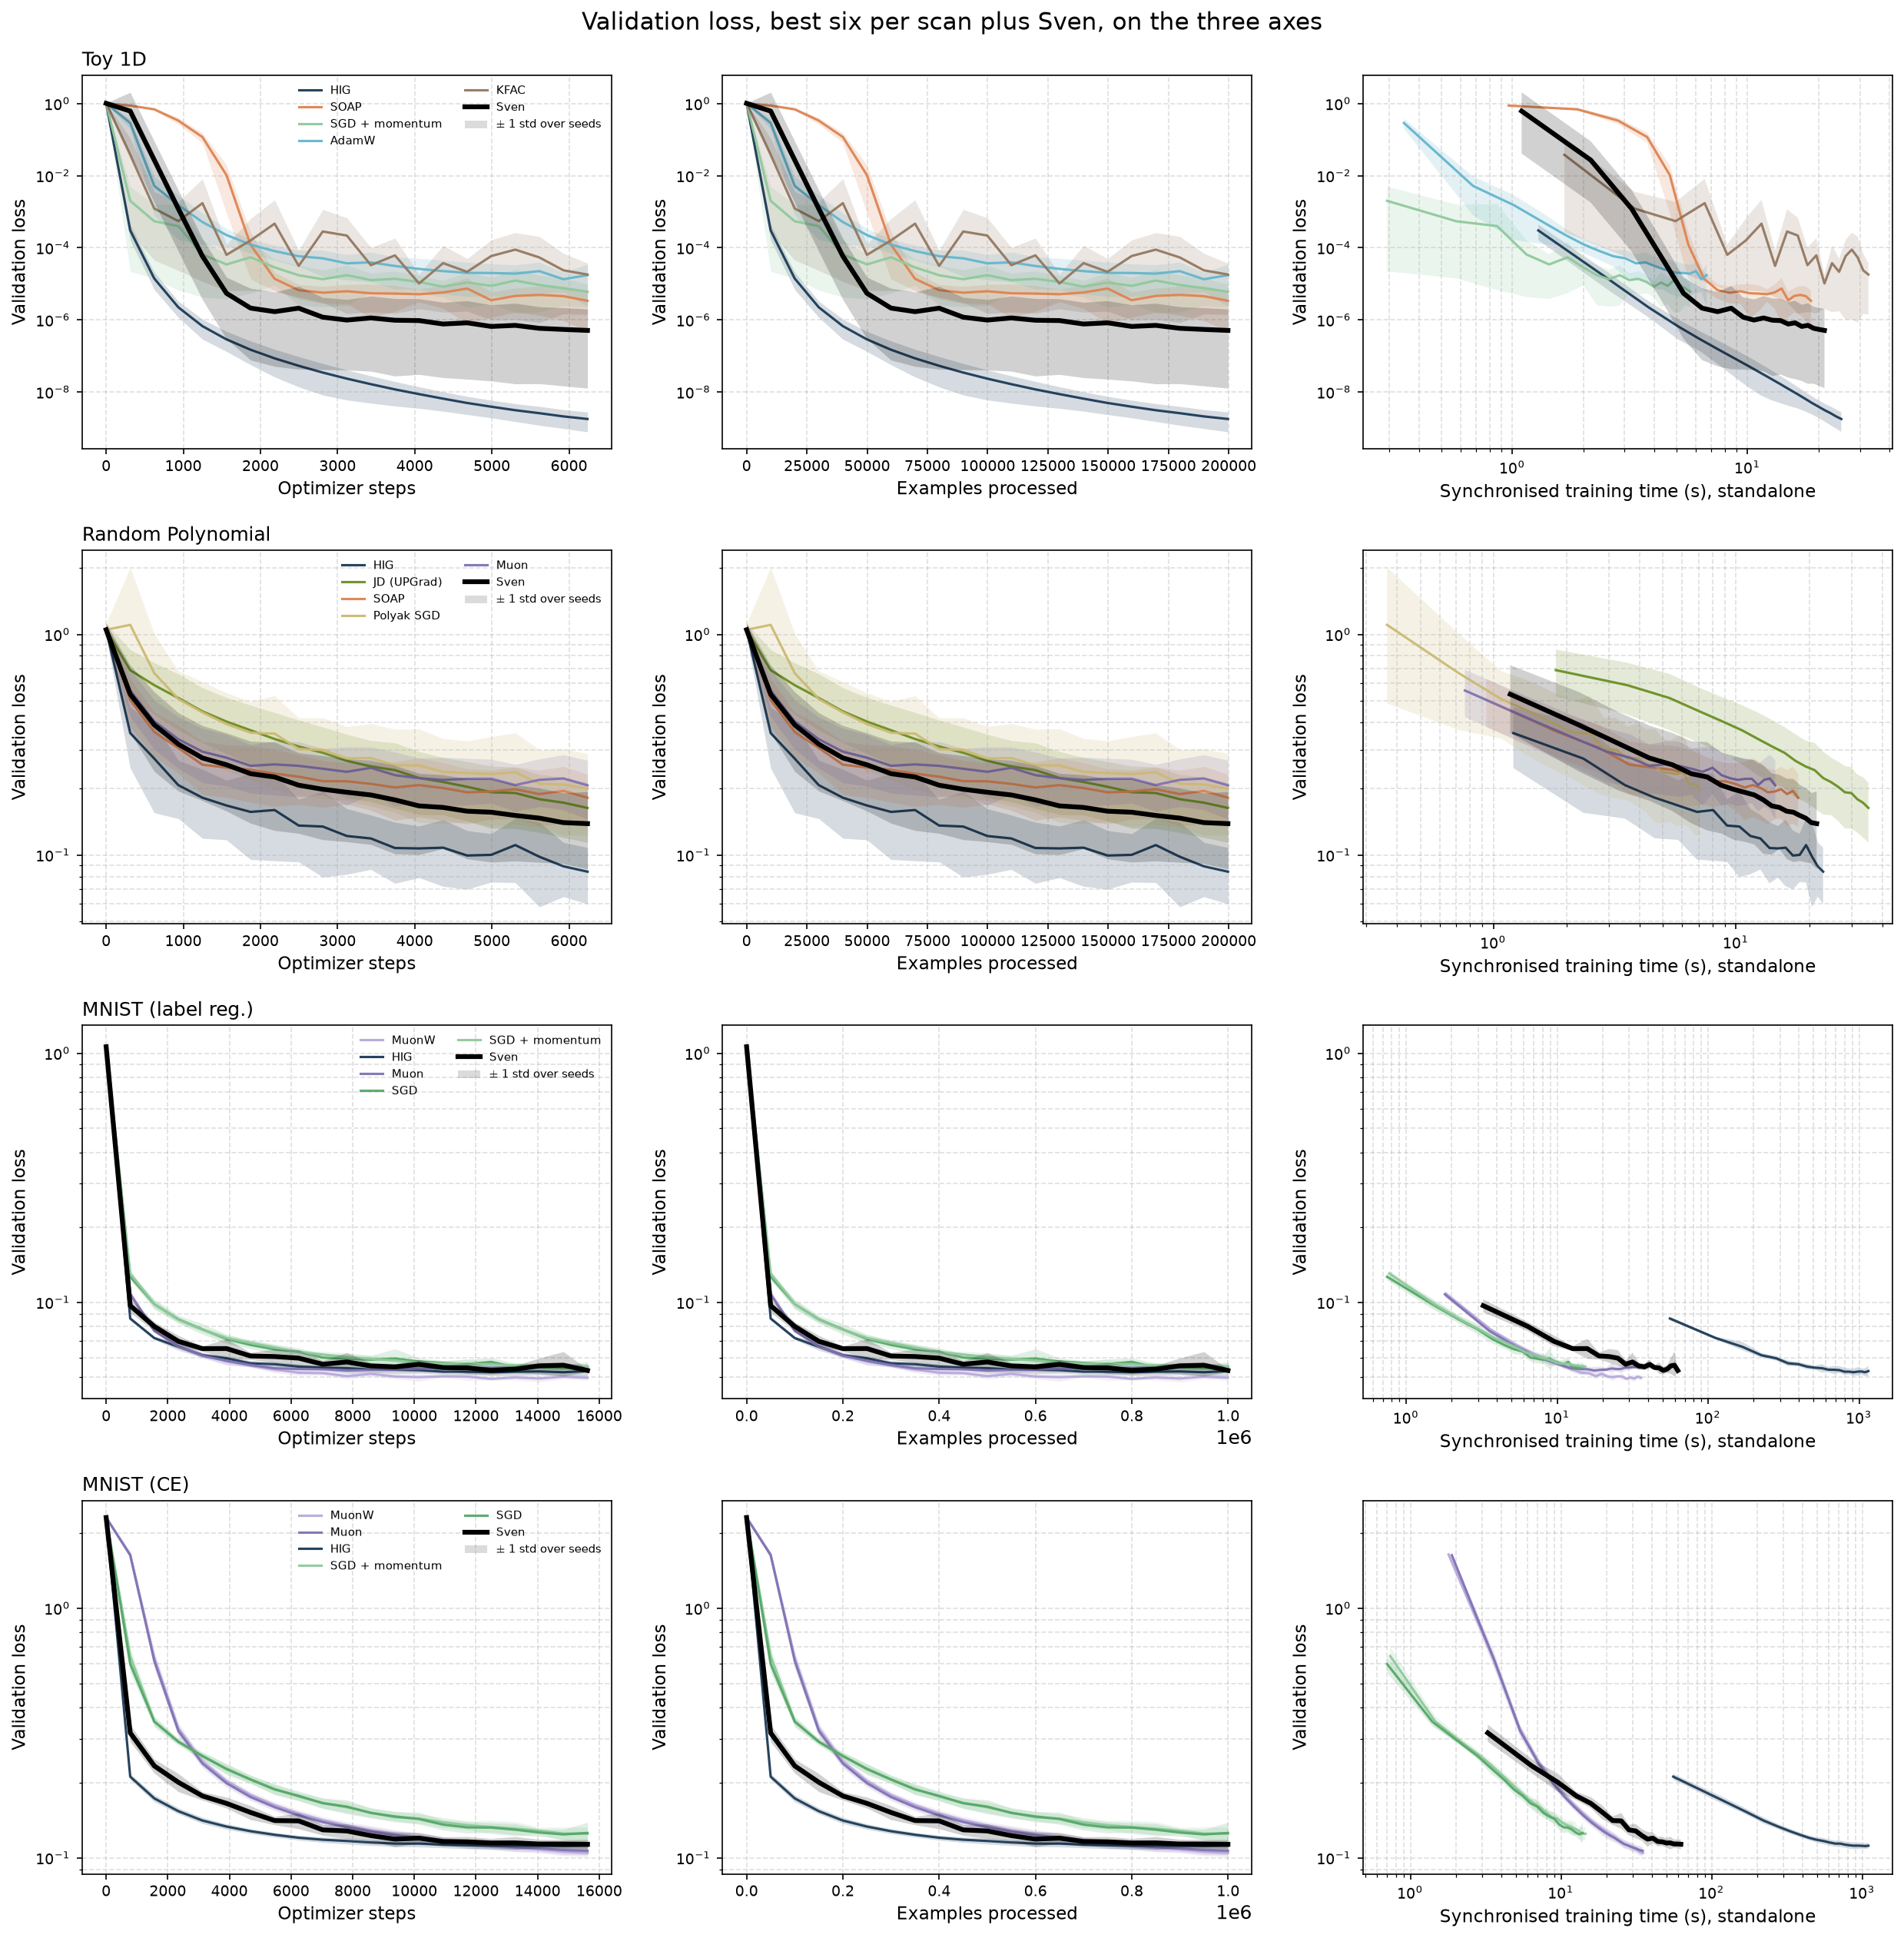

In [7]:
def grid_figure(top_only, stem, title):
    fig, axes = plt.subplots(len(SCANS), len(hf.CURVE_AXES),
                             figsize=(5.6 * len(hf.CURVE_AXES), 4.3 * len(SCANS)),
                             squeeze=False)
    for i, name in enumerate(SCANS):
        ms = order[name]
        if top_only:
            ms = ms[:6] + ([hl.SVEN_LABEL] if hl.SVEN_LABEL not in ms[:6] else [])
        for j, versus in enumerate(hf.CURVE_AXES):
            ax = axes[i][j]
            hf.plot_curves(name, ax, which='val', versus=versus, methods=ms,
                           runs=runs[name], times=times[name],
                           lw=1.5 if top_only else 1.1, alpha=0.95 if top_only else 0.75,
                           quiet=True)
            ax.xaxis.label.set_size(11); ax.yaxis.label.set_size(11)
            ax.tick_params(labelsize=9)
            if j == 0:
                ax.set_title(hl.scan_title(name), fontsize=12, loc='left')
        axes[i][0].legend(fontsize=7, ncol=2 if top_only else 3, framealpha=0.95)
    fig.suptitle(title, fontsize=15)
    fig.tight_layout()
    hf.save(fig, PLOT_DIR, stem)
    plt.show()

grid_figure(True, 'val_curves_three_axes_top6',
            'Validation loss, best six per scan plus Sven, on the three axes')

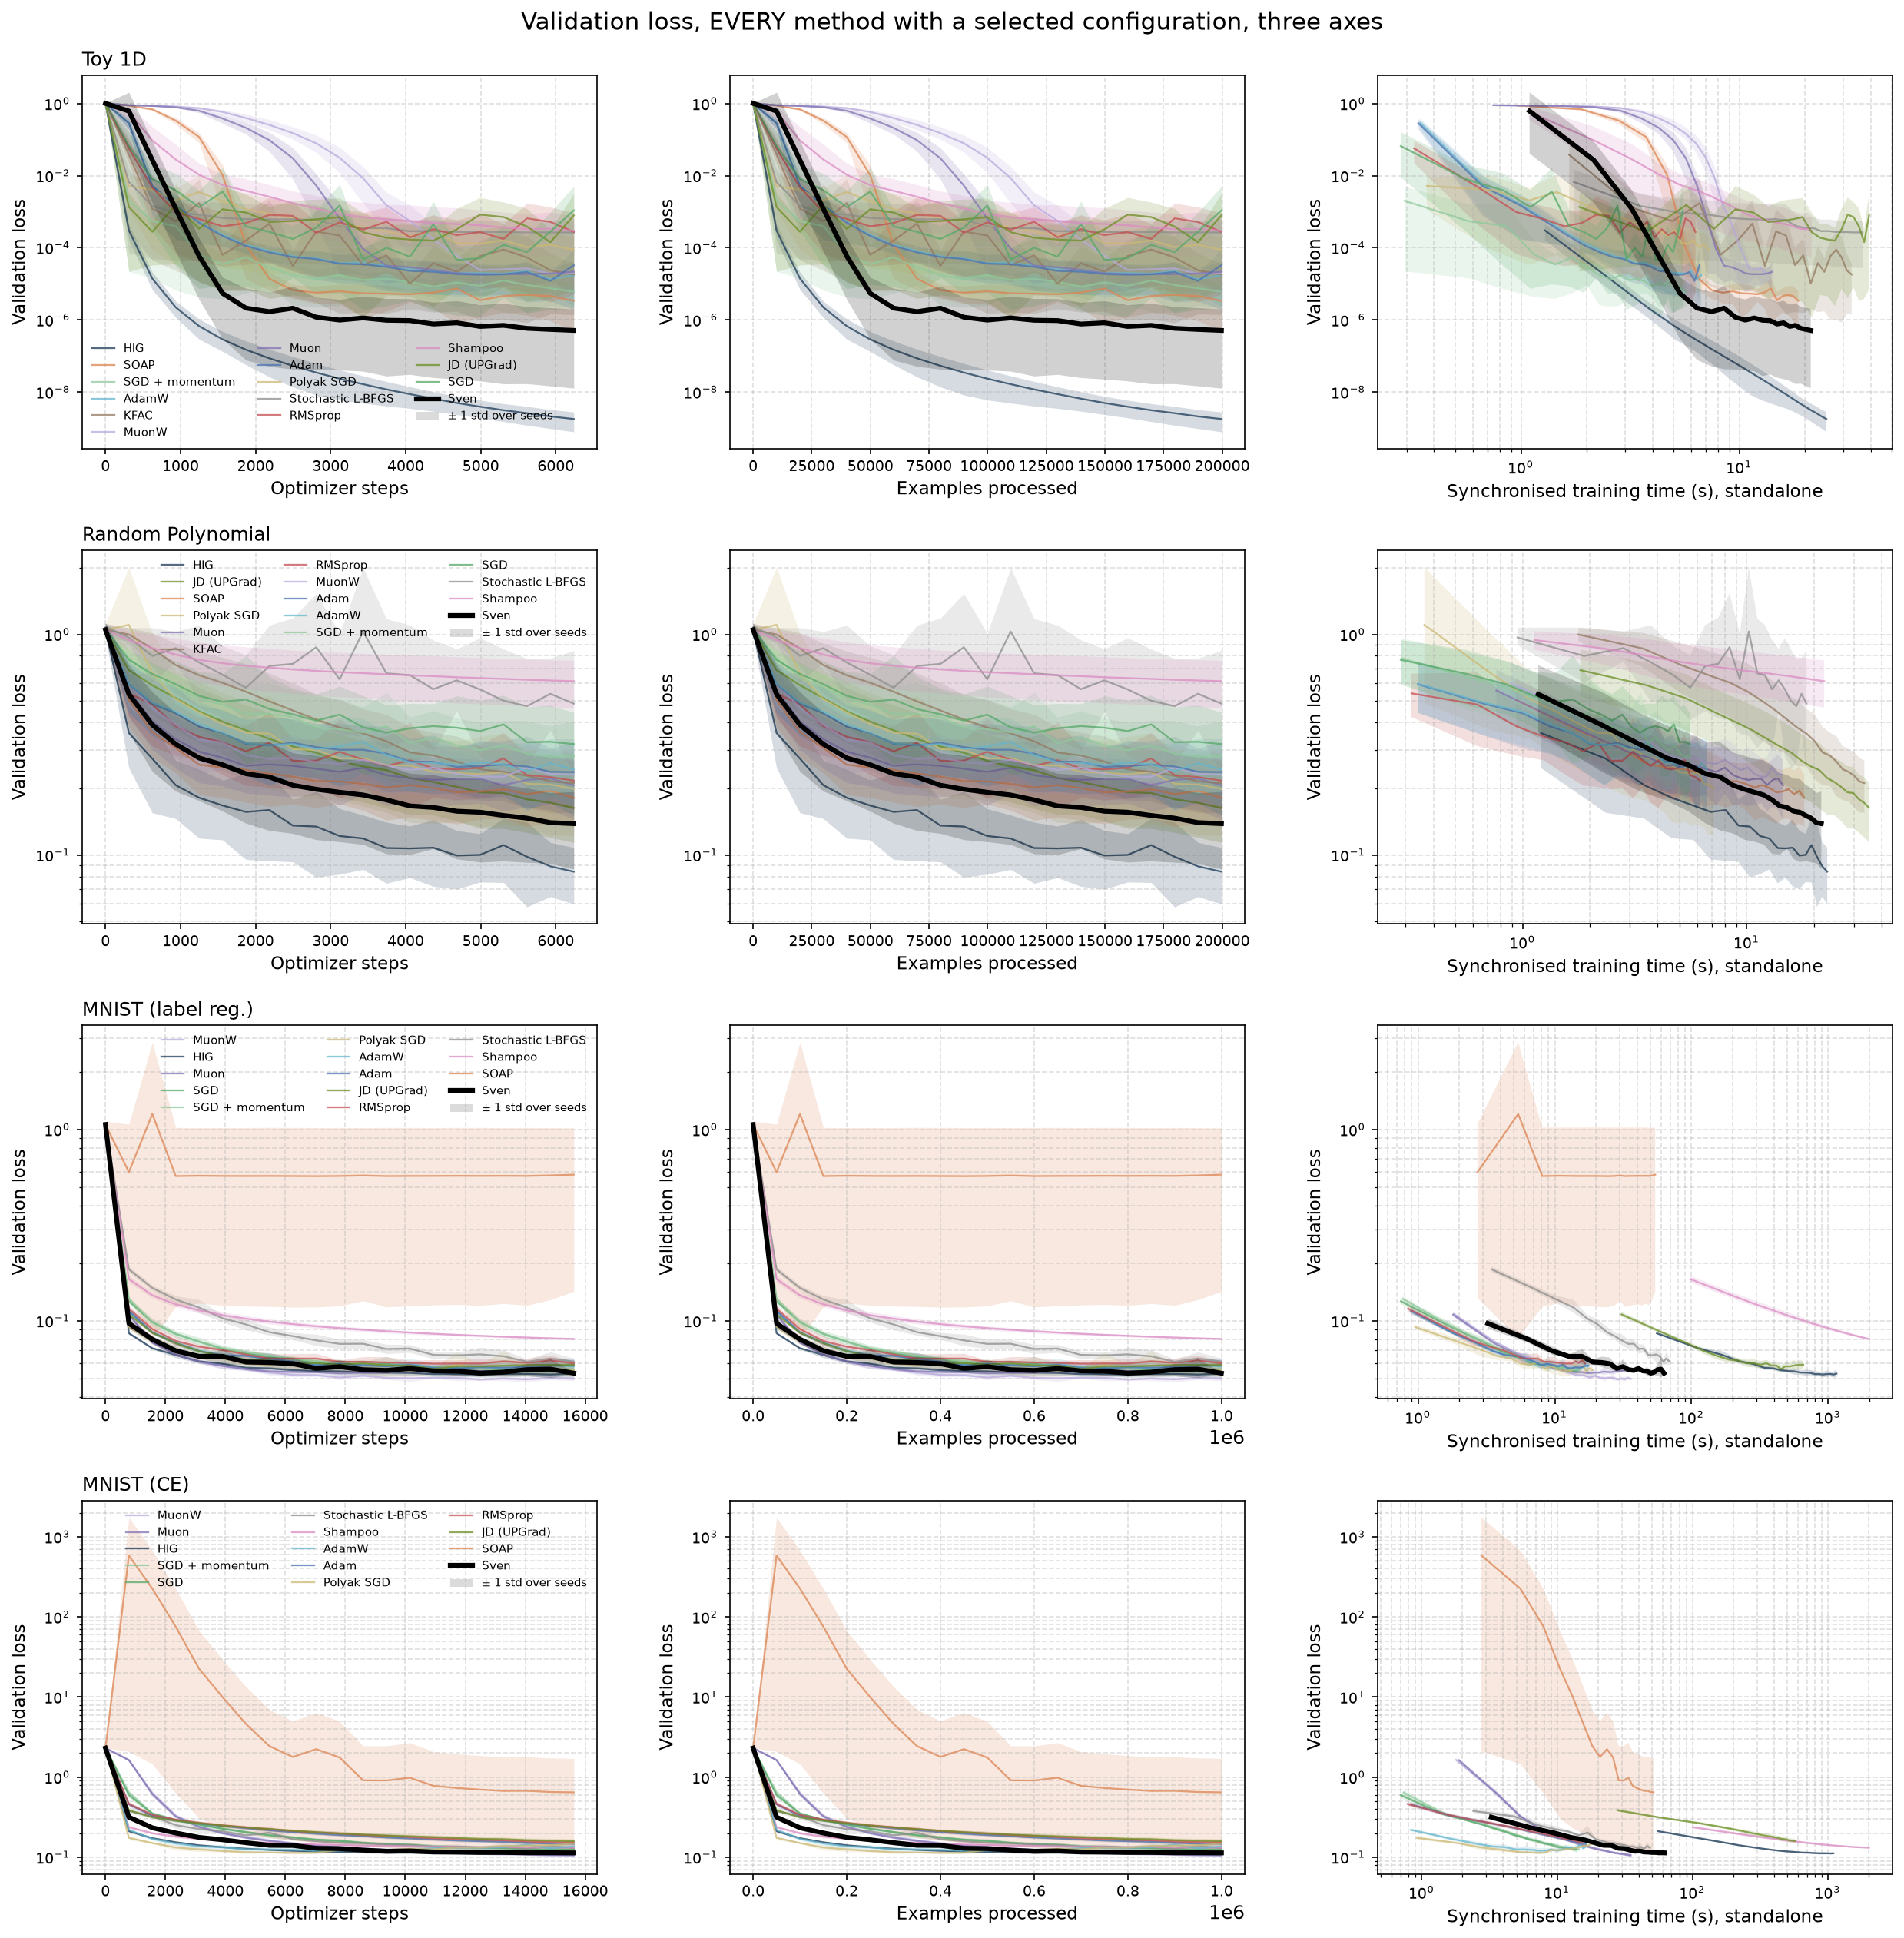

In [8]:
grid_figure(False, 'val_curves_three_axes_all',
            'Validation loss, EVERY method with a selected configuration, three axes')

## 4. Paired differences against Sven

One panel per scan.  The difference is taken **within a pair** --- same model seed, hence
the same initialisation and data order (and, on toy / polynomial, the same problem
instance) --- and the bar is a Student-*t* interval on the **mean difference**, not the
seed band.  `mean = Sven − other`, so a bar entirely left of the red line means Sven had
the lower validation loss on every pair by more than the interval.  With 5 (or 15) pairs
and 13--14 comparisons per scan and no multiplicity correction, "excludes zero" is a
reading aid, not a test.

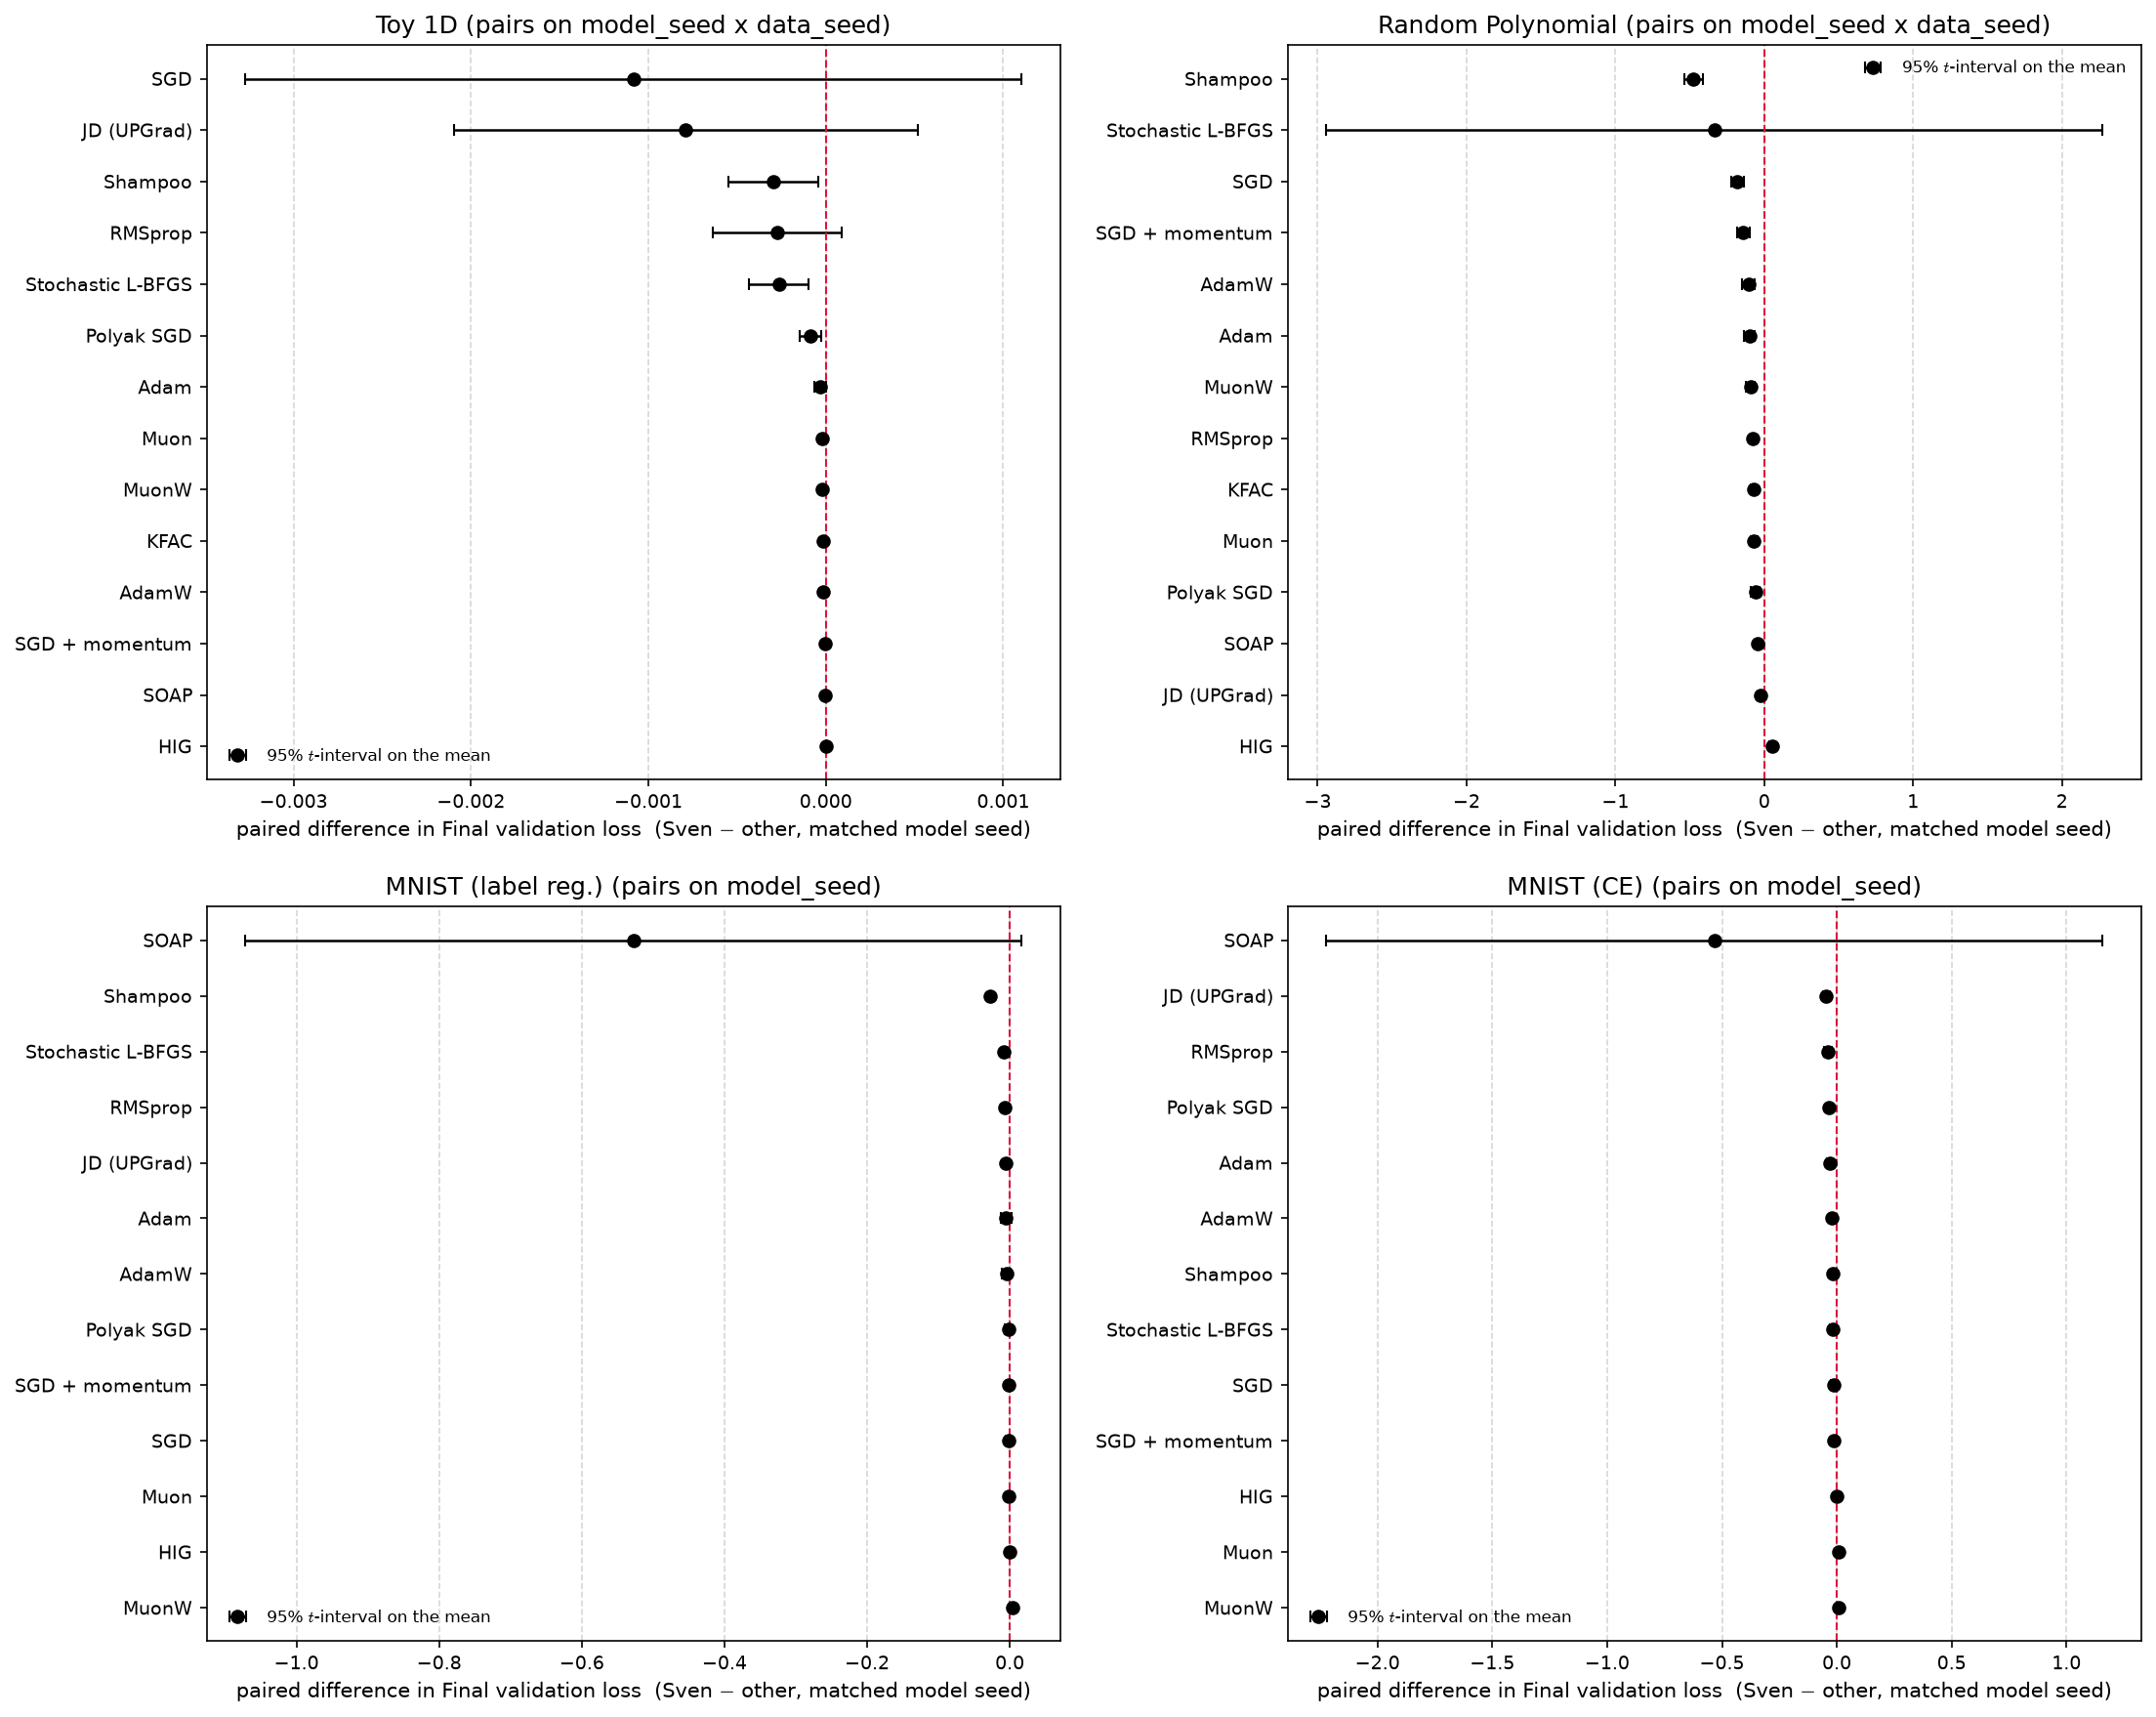


### Toy 1D -- paired Sven − method, final validation loss, 95% $t$-interval on the mean
| display | n | mean | half_width | ci_low | ci_high | n_unpaired | sven_better | significant |
|---|---|---|---|---|---|---|---|---|
| SGD | 15 | -0.001084 | 0.002187 | -0.003271 | 0.001103 | 0 | 15 | False |
| JD (UPGrad) | 15 | -0.0007888 | 0.001307 | -0.002096 | 0.0005179 | 0 | 15 | False |
| Shampoo | 15 | -0.0002951 | 0.0002517 | -0.0005469 | -4.339e-05 | 0 | 15 | True |
| RMSprop | 15 | -0.0002741 | 0.000365 | -0.0006391 | 9.088e-05 | 0 | 15 | False |
| Stochastic L-BFGS | 14 | -0.0002654 | 0.0001689 | -0.0004343 | -9.644e-05 | 1 | 14 | True |
| Polyak SGD | 15 | -8.741e-05 | 5.876e-05 | -0.0001462 | -2.865e-05 | 0 | 15 | True |
| Adam | 15 | -3.213e-05 | 3.201e-05 | -6.414e-05 | -1.166e-07 | 0 | 15 | True |
| Muon | 15 | -2.108e-05 | 1.095e-05 | -3.202e-05 | -1.013e-05 | 0 | 15 | True |
| MuonW | 15 | -1.877e-05 | 4.867e-06 | -2.364e-05 | -1.39e-05 | 0 | 15 | True |
| KFAC | 15 | -1.751e-05

In [9]:
PCOLS = ['display', 'n', 'mean', 'half_width', 'ci_low', 'ci_high', 'n_unpaired',
         'sven_better', 'significant']
pv = {}
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
for ax, name in zip(axes.ravel(), SCANS):
    pv[name] = hl.paired_vs_sven(name)
    paired.plot_paired(pv[name], ax, label_col='display')
    ax.set_title(f'{hl.scan_title(name)} (pairs on {pv[name].attrs["pair_on"]})',
                 fontsize=12)
    ax.xaxis.label.set_size(10); ax.tick_params(labelsize=9)
fig.tight_layout()
hf.save(fig, PLOT_DIR, 'paired_vs_sven')
plt.show()

for name in SCANS:
    hl.print_table(pv[name][PCOLS], f'{hl.scan_title(name)} -- paired Sven − method, '
                                    f'final validation loss, {paired.interval_label(0.95)}')
    print(f'  sign: {pv[name].attrs["sign"]}')

In [10]:
# The same comparison on the test OUTCOMES, as a count: on how many of the paired seeds
# did Sven win?  (headline.paired_outcome_vs_sven; paired.py refuses a test metric by
# design.)  The accuracy tables count wins in the ACCURACY direction -- reading them under
# the loss convention turns a clean sweep into its opposite.
for metric in ('final_test_loss', 'final_test_acc'):
    got = {}
    for name in SCANS:
        t = hl.paired_outcome_vs_sven(name, metric=metric)
        if not t.empty:
            got[name] = t.assign(wins=[f'{int(w)}/{int(n)}'
                                       for w, n in zip(t['sven_better'], t['n'])])
    if got:
        hl.print_table(hf.scan_matrix(got, 'wins').reset_index(),
                       f'Pairs Sven won on {metric} (an OUTCOME) -- '
                       + ('higher is better' if 'acc' in metric else 'lower is better'))


### Pairs Sven won on final_test_loss (an OUTCOME) -- lower is better
| display | Toy 1D | Random Polynomial | MNIST (label reg.) | MNIST (CE) |
|---|---|---|---|---|
| Adam | 15/15 | 14/15 | 4/5 | 5/5 |
| AdamW | 15/15 | 14/15 | 4/5 | 5/5 |
| HIG | 0/15 | 0/15 | 2/5 | 1/5 |
| JD (UPGrad) | 15/15 | 13/15 | 4/5 | 5/5 |
| KFAC | 15/15 | 15/15 |  |  |
| Muon | 15/15 | 14/15 | 3/5 | 0/5 |
| MuonW | 15/15 | 14/15 | 0/5 | 0/5 |
| Polyak SGD | 15/15 | 15/15 | 5/5 | 5/5 |
| RMSprop | 15/15 | 14/15 | 5/5 | 5/5 |
| SGD | 15/15 | 15/15 | 4/5 | 4/5 |
| SGD + momentum | 14/15 | 15/15 | 4/5 | 4/5 |
| SOAP | 14/15 | 13/15 | 5/5 | 3/4 |
| Shampoo | 15/15 | 15/15 | 5/5 | 5/5 |
| Stochastic L-BFGS | 14/14 | 2/2 | 5/5 | 4/4 |



### Pairs Sven won on final_test_acc (an OUTCOME) -- higher is better
| display | MNIST (label reg.) | MNIST (CE) |
|---|---|---|
| Adam | 3/5 | 5/5 |
| AdamW | 3/5 | 2/5 |
| HIG | 5/5 | 2/5 |
| JD (UPGrad) | 4/5 | 5/5 |
| Muon | 4/5 | 0/5 |
| MuonW | 0/5 | 1/5 |
| Polyak SGD | 3/5 | 1/5 |
| RMSprop | 5/5 | 5/5 |
| SGD | 0/5 | 4/5 |
| SGD + momentum | 0/5 | 5/5 |
| SOAP | 5/5 | 3/4 |
| Shampoo | 5/5 | 5/5 |
| Stochastic L-BFGS | 4/5 | 4/4 |


## 5. Tuning budget: is the suite compared at an equal search effort?

Sven's grid is 128--180 points on three axes; most baselines get four to nine learning
rates.  `distinct_frac` says how much of Sven's grid bought anything (a point whose
rtol-rank never reaches $k$ truncates nothing extra and is the *identical* trajectory), and
the best-of-$n$ curves put every method at the **same** budget $n$: the expected best
seed-mean validation loss when $n$ configurations are drawn at random from that method's
grid.  A configuration no seed finished is scored at the worst seed mean in the scan,
because a random search would still have spent a trial on it.

In [11]:
hl.print_table(hf.scan_matrix({s: t.rename(columns={'label': 'display'})
                               for s, t in bt.items()}, 'grid_points').reset_index(),
               'Grid points per method')
hl.print_table(hf.scan_matrix({s: t.rename(columns={'label': 'display'})
                               for s, t in bt.items()}, 'distinct').reset_index(),
               'DISTINCT trajectories per method (what the search actually explored)')
hl.print_table(hf.scan_matrix({s: t.rename(columns={'label': 'display'})
                               for s, t in bt.items()}, 'distinct_frac').reset_index(),
               'distinct / grid points')


### Grid points per method
| display | Toy 1D | Random Polynomial | MNIST (label reg.) | MNIST (CE) |
|---|---|---|---|---|
| Sven | 180 | 144 | 128 | 160 |
| Adam | 8 | 10 | 8 | 8 |
| AdamW | 8 | 10 | 8 | 8 |
| HIG | 42 | 30 | 30 | 30 |
| JD (UPGrad) | 6 | 6 | 6 | 6 |
| KFAC | 8 | 10 | 8 | 8 |
| Muon | 8 | 10 | 8 | 8 |
| MuonW | 8 | 10 | 8 | 8 |
| Polyak SGD | 1 | 1 | 1 | 1 |
| RMSprop | 8 | 10 | 8 | 8 |
| SGD | 8 | 10 | 8 | 8 |
| SGD + momentum | 8 | 10 | 8 | 8 |
| SOAP | 8 | 10 | 8 | 8 |
| Shampoo | 8 | 10 | 8 | 8 |
| Stochastic L-BFGS | 45 | 45 | 27 | 45 |

### DISTINCT trajectories per method (what the search actually explored)
| display | Toy 1D | Random Polynomial | MNIST (label reg.) | MNIST (CE) |
|---|---|---|---|---|
| Sven | 115 | 89 | 60.8 | 106.2 |
| Adam | 8 | 10 | 8 | 8 |
| AdamW | 8 | 10 | 8 | 8 |
| HIG | 41.6 | 21.8 | 29.6 | 20.4 |
| JD (UPGrad) | 6 | 6 | 6 | 6 |
| KFAC | 8 | 10 | 8 | 8 |
| Muon | 8 | 10 | 8 | 8 |
| MuonW | 8 | 10 | 8 | 8 |
| Polyak SGD | 1 | 1 | 1 |

,display,Toy 1D,Random Polynomial,MNIST (label reg.),MNIST (CE)
0,Sven,0.638889,0.618056,0.475000,0.663750
1,Adam,1.000000,1.000000,1.000000,1.000000
2,AdamW,1.000000,1.000000,1.000000,1.000000
3,HIG,0.990476,0.726667,0.986667,0.680000
4,JD (UPGrad),1.000000,1.000000,1.000000,1.000000
5,KFAC,1.000000,1.000000,1.000000,1.000000
6,Muon,1.000000,1.000000,1.000000,1.000000
7,MuonW,1.000000,1.000000,1.000000,1.000000
8,Polyak SGD,1.000000,1.000000,1.000000,1.000000
9,RMSprop,1.000000,1.000000,1.000000,1.000000


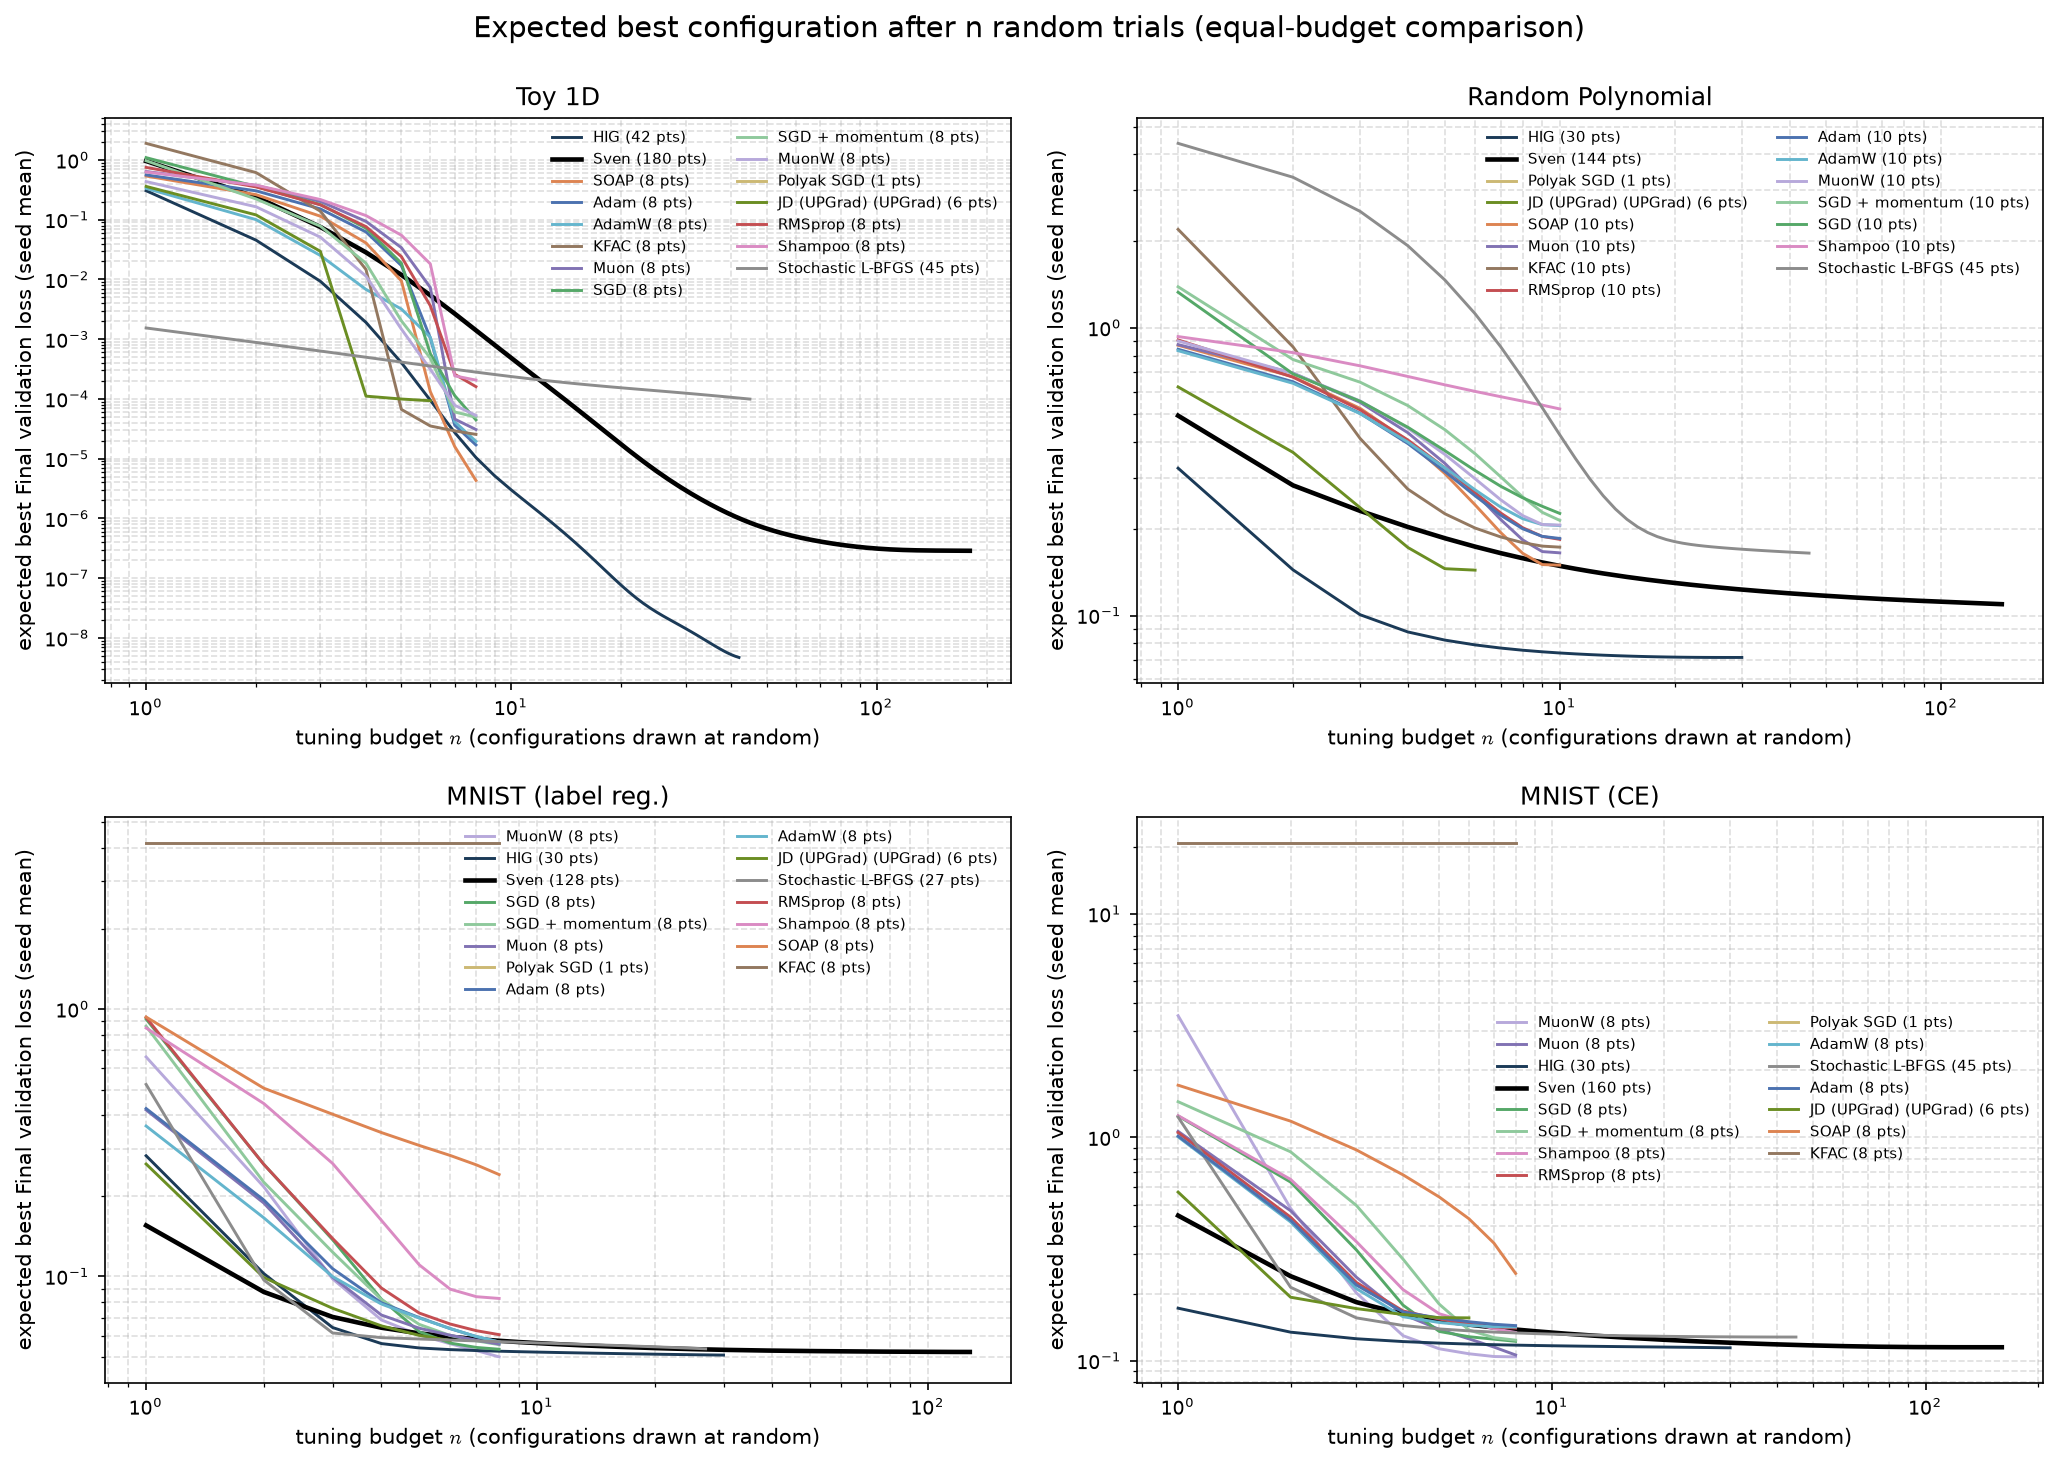


### Toy 1D -- expected best seed-mean val loss at budget n
| method | grid_points | 1 | 2 | 4 | 8 | 16 | 32 | 64 | 128 |
|---|---|---|---|---|---|---|---|---|---|
| Sven | 180 | 0.9604 | 0.2403 | 0.02839 | 0.001413 | 5.151e-05 | 2.339e-06 | 4.565e-07 | 2.927e-07 |
| Stochastic L-BFGS | 45 | 0.001542 | 0.0008824 | 0.0004992 | 0.0002813 | 0.0001736 | 0.0001207 |  |  |
| HIG | 42 | 0.3063 | 0.04551 | 0.001908 | 1.046e-05 | 2.716e-07 | 1.141e-08 |  |  |
| AdamW | 8 | 0.3349 | 0.1004 | 0.006805 | 1.948e-05 |  |  |  |  |
| KFAC | 8 | 1.898 | 0.615 | 0.01465 | 2.552e-05 |  |  |  |  |
| Muon | 8 | 0.6409 | 0.3769 | 0.09385 | 3.079e-05 |  |  |  |  |
| Adam | 8 | 0.5622 | 0.3047 | 0.06242 | 1.698e-05 |  |  |  |  |
| SOAP | 8 | 0.5392 | 0.2626 | 0.04087 | 4.325e-06 |  |  |  |  |
| MuonW | 8 | 0.4351 | 0.1647 | 0.01135 | 5.294e-05 |  |  |  |  |
| SGD | 8 | 1.095 | 0.3595 | 0.07227 | 4.458e-05 |  |  |  |  |
| RMSprop | 8 | 0.7514 | 0.3547 | 0.07666 | 0.0001607 |  |  |  |  |
| Shampoo | 8 | 0.6305 

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
bon, bon_curves = {}, {}
for ax, name in zip(axes.ravel(), SCANS):
    curves, at_n = hl.best_of_n_table(name)
    bon[name], bon_curves[name] = at_n, curves
    budget.plot_best_of_n(curves, ax)
    hf.relabel_methods(ax, fontsize=7, ncol=2)
    ax.set_title(hl.scan_title(name), fontsize=12)
    ax.xaxis.label.set_size(10); ax.yaxis.label.set_size(10); ax.tick_params(labelsize=9)
fig.suptitle('Expected best configuration after n random trials (equal-budget comparison)',
             fontsize=14)
fig.tight_layout()
hf.save(fig, PLOT_DIR, 'best_of_n')
plt.show()

for name in SCANS:
    hl.print_table(bon[name].reset_index().rename(columns={'index': 'method'}),
                   f'{hl.scan_title(name)} -- expected best seed-mean val loss at budget n')

In [13]:
# The equal-budget answer, as a cross-scan matrix and as Sven's rank in it: every method
# read at n = BUDGET_EQUAL_N random trials (a grid smaller than n is read at its own size,
# i.e. exhausted).  This is the number that answers the budget objection -- and on three
# of the four scans it answers it against Sven.
eq = {name: hf.equal_budget_table(bon_curves[name]) for name in SCANS}
hl.print_table(hf.scan_matrix(eq, 'expected_best').reset_index(),
               f'Expected best seed-mean validation loss at an EQUAL budget of '
               f'n = {hf.BUDGET_EQUAL_N} random trials')
hl.print_table(hf.scan_matrix(eq, 'n_used').reset_index(),
               'Trials actually available at that budget (= min(n, grid points))')
for name in SCANS:
    e = eq[name]
    i = int(e[e['method'] == 'Sven'].index[0])
    hit = bon_curves[name][(bon_curves[name]['method'] == 'Sven')
                           & (bon_curves[name]['expected_best']
                              <= e['expected_best'].iloc[0])]
    need = int(hit['n'].iloc[0]) if len(hit) else None
    print(f'{hl.scan_title(name):28s} Sven {i + 1}/{len(e)} at n = {hf.BUDGET_EQUAL_N} '
          f'({i} method(s) better); best = {e["display"].iloc[0]} '
          f'{e["expected_best"].iloc[0]:.4g}; Sven matches it at n = '
          + (str(need) if need else 'never, anywhere on its grid'))


### Expected best seed-mean validation loss at an EQUAL budget of n = 8 random trials
| display | Toy 1D | Random Polynomial | MNIST (label reg.) | MNIST (CE) |
|---|---|---|---|---|
| Sven | 0.001413 | 0.1581 | 0.05742 | 0.138 |
| Adam | 1.698e-05 | 0.2001 | 0.05683 | 0.1436 |
| AdamW | 1.948e-05 | 0.2169 | 0.05686 | 0.1417 |
| HIG | 1.046e-05 | 0.07575 | 0.0525 | 0.1175 |
| JD (UPGrad) | 9.335e-05 | 0.1438 | 0.05756 | 0.1556 |
| KFAC | 2.552e-05 | 0.1791 | 4.186 | 20.81 |
| Muon | 3.079e-05 | 0.183 | 0.0558 | 0.1061 |
| MuonW | 5.294e-05 | 0.2223 | 0.04999 | 0.1041 |
| Polyak SGD | 9.204e-05 | 0.1362 | 0.05678 | 0.1408 |
| RMSprop | 0.0001607 | 0.2018 | 0.06054 | 0.1401 |
| SGD | 4.458e-05 | 0.2564 | 0.05338 | 0.1222 |
| SGD + momentum | 4.964e-05 | 0.2581 | 0.05554 | 0.1237 |
| SOAP | 4.325e-06 | 0.1644 | 0.2403 | 0.246 |
| Shampoo | 0.0002068 | 0.5557 | 0.08268 | 0.1339 |
| Stochastic L-BFGS | 0.0002813 | 0.6676 | 0.05699 | 0.1332 |

### Trials actually available at that budget (=

## 6. Cost and time to target

Times are from `{scan}_timing/` only: the selected configuration, one at a time, alone on a
GPU.  `epoch_s` is the standalone wall clock of an epoch, `ms_per_step` the synchronised
training time per optimizer step (evaluation excluded), `peak_gpu_mem_mb` the peak
allocation.  The scans themselves ran several trainings per GPU **and** mostly on an
A100-40GB MIG 3g.20gb slice while every timing run had a full A100-80GB, so the scan's own
wall times are not comparable with these and are not used.

The targets are pre-declared (`headline.TARGET_MULTIPLIERS`): the **median** method's
confirmation-seed final validation loss and 2x / 0.5x of it --- validation only, so
declaring a target cannot leak the test split, and the median rather than the best, because
a target set by the winner is a target only the winner reaches.  Runs that never get there
are counted, split into `n_never_reached` (trained to the end, never arrived) and
`n_diverged` (no trajectory to ask).

In [14]:
for col, label in (('epoch_s', 'Seconds per epoch, standalone'),
                   ('ms_per_step', 'Synchronised ms per optimizer step'),
                   ('peak_gpu_mem_mb', 'Peak GPU memory (MB)')):
    hl.print_table(hf.scan_matrix(eff, col).reset_index(), label)
hl.print_table(hf.scan_matrix(eff, 'wall_vs_sven').reset_index(),
               'Standalone total wall time relative to Sven (< 1 = cheaper than Sven)')
for name in SCANS:
    print(f'{hl.scan_title(name):28s} {eff[name].attrs["inflation_means"]}')


### Seconds per epoch, standalone
| display | Toy 1D | Random Polynomial | MNIST (label reg.) | MNIST (CE) |
|---|---|---|---|---|
| Sven | 1.309 | 1.329 | 3.738 | 3.724 |
| Adam | 0.5658 | 0.5802 | 1.478 | 1.391 |
| AdamW | 0.5729 | 0.5803 | 1.464 | 1.397 |
| HIG | 1.503 | 1.401 | 58.26 | 55.54 |
| JD (UPGrad) | 2.208 | 2.014 | 33.53 | 29.09 |
| KFAC | 1.88 | 1.923 |  |  |
| Muon | 0.9463 | 0.9785 | 2.343 | 2.33 |
| MuonW | 0.9423 | 0.9667 | 2.398 | 2.343 |
| Polyak SGD | 0.6215 | 0.6264 | 1.552 | 1.51 |
| RMSprop | 0.5486 | 0.5552 | 1.41 | 1.348 |
| SGD | 0.5111 | 0.5278 | 1.329 | 1.277 |
| SGD + momentum | 0.5185 | 0.5254 | 1.353 | 1.315 |
| SOAP | 1.174 | 1.149 | 3.336 | 3.175 |
| Shampoo | 1.314 | 1.363 | 100.3 | 101.4 |
| Stochastic L-BFGS | 2.089 | 1.194 | 4.072 | 3.054 |

### Synchronised ms per optimizer step
| display | Toy 1D | Random Polynomial | MNIST (label reg.) | MNIST (CE) |
|---|---|---|---|---|
| Sven | 3.4 | 3.443 | 4.028 | 3.998 |
| Adam | 1.051 | 1.061 | 1.132 | 

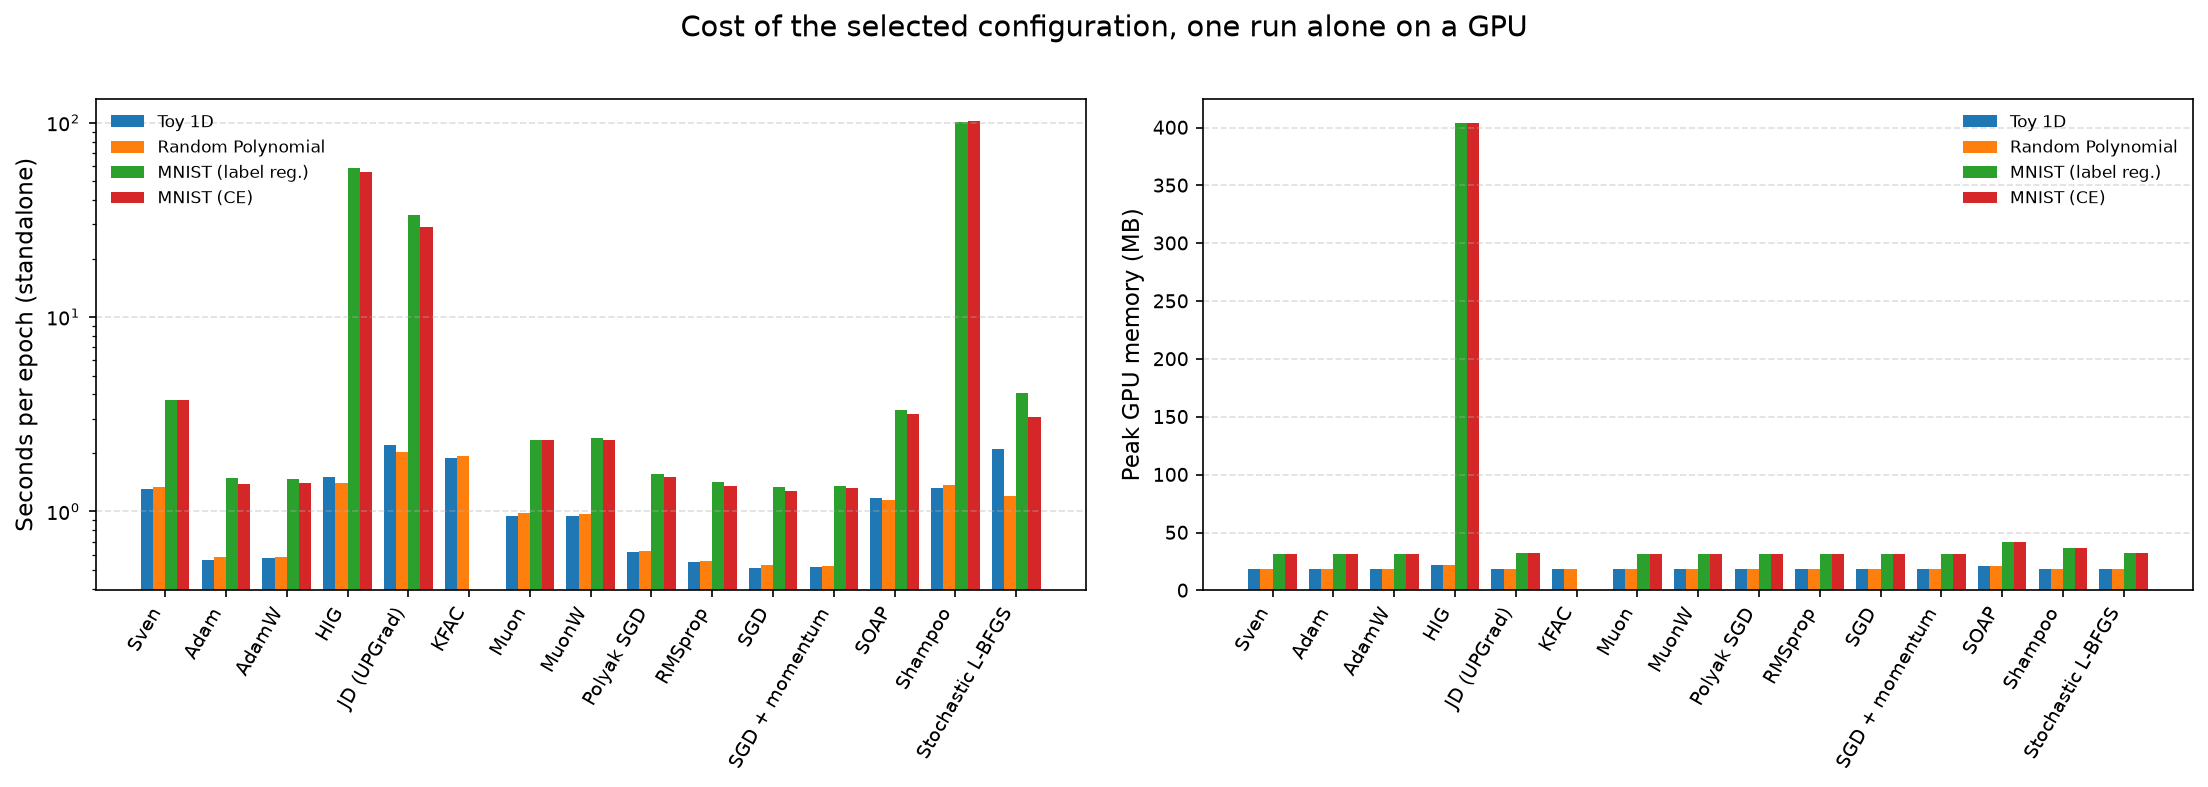

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))
for ax, (col, label, logy) in zip(axes, [('epoch_s', 'Seconds per epoch (standalone)', True),
                                         ('peak_gpu_mem_mb', 'Peak GPU memory (MB)', False)]):
    m = hf.scan_matrix(eff, col)
    width = 0.8 / len(m.columns)
    x = np.arange(len(m))
    for j, c in enumerate(m.columns):
        ax.bar(x + (j - (len(m.columns) - 1) / 2) * width, m[c], width, label=c)
    ax.set_xticks(x)
    ax.set_xticklabels(m.index, rotation=60, ha='right', fontsize=9)
    ax.set_ylabel(label, fontsize=11)
    if logy:
        ax.set_yscale('log')
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(axis='y', ls='--', alpha=0.4)
    ax.legend(fontsize=8)
fig.suptitle('Cost of the selected configuration, one run alone on a GPU', fontsize=14)
fig.tight_layout()
hf.save(fig, PLOT_DIR, 'standalone_cost_by_scan')
plt.show()

In [16]:
# Time to the median-method target, per scan: the epochs, the synchronised training
# seconds, and how many runs never got there at all.
MEDIAN = hl.TARGET_NAMES[1.0]
med = {s: t[t['target'] == MEDIAN] for s, t in ttt.items()}
for col, label in (('epochs', f'Epochs to the "{MEDIAN}" target'),
                   ('sync_train_s', f'Synchronised training seconds to the "{MEDIAN}" target'),
                   ('n_reached', 'Confirmation runs that reached it'),
                   ('n_never_reached', 'Runs that trained to the end and never reached it'),
                   ('n_diverged', 'Runs with no trajectory to ask (diverged)')):
    hl.print_table(hf.scan_matrix(med, col).reset_index(), label)
for name in SCANS:
    print(f'{hl.scan_title(name):28s} targets: '
          + ', '.join(f'{k} = {v:.4g}' for k, v in ttt[name].attrs['targets'].items()))


### Epochs to the "median method" target
| display | Toy 1D | Random Polynomial | MNIST (label reg.) | MNIST (CE) |
|---|---|---|---|---|
| Sven | 4.667 | 7.286 | 9.2 | 9.8 |
| Adam | 11.93 | 10.2 | 12.67 |  |
| AdamW | 12.57 | 11.2 | 13.25 | 5.8 |
| HIG | 2.2 | 3.533 | 7 | 6 |
| JD (UPGrad) | 7.857 | 12.69 | 11 |  |
| KFAC | 6.867 | 15.5 |  |  |
| Muon | 12.93 | 6 | 6 | 11 |
| MuonW | 16.36 | 8.4 | 6 | 11.2 |
| Polyak SGD | 11.25 | 10 | 9.6 | 3.6 |
| RMSprop | 13.69 | 8.7 | 12.33 |  |
| SGD | 10.17 | 17.5 | 14.2 | 15.75 |
| SGD + momentum | 6 | 16.89 | 13.75 | 16.75 |
| SOAP | 7.067 | 6.667 |  | 13.33 |
| Shampoo |  |  |  | 15 |
| Stochastic L-BFGS |  |  |  | 15.75 |

### Synchronised training seconds to the "median method" target
| display | Toy 1D | Random Polynomial | MNIST (label reg.) | MNIST (CE) |
|---|---|---|---|---|
| Sven | 13.68 | 21.21 | 83.18 | 81.81 |
| Adam | 7.995 | 9.334 | 24.34 |  |
| AdamW | 11.45 | 10.65 | 28.65 | 12.55 |
| HIG | 15.14 | 16.11 | 2418 | 2028 |
| J

## 7. Robustness across the tuning grids

The fraction of each method's **whole tuning grid** that blew up, under the analysis rule
`style.is_diverged` (recorded `diverged`, *or* a non-finite final value, *or* a finite
blow-up past 10x the initial validation loss) --- the rule that governs selection.  The
second matrix is the narrow, lifecycle count (`status == "diverged"`), and the two are
different questions: on `toy_1d_scan` Sven's are 0 and 194.  The campaign-wide pair is
printed below, **recomputed** from every tuning grid in the results root rather than
quoted from `EXPERIMENTS.md` section 7, whose denominator was fixed before the CIFAR-CE
`rtol` extension started adding Sven runs to it.  Any robustness claim made from the
status field alone is wrong.

Where those divergences sit is a per-scan question: the verdicts printed after the
heatmaps are computed from each grid's own counts, and on two of these four scans the
honest verdict is "none anywhere".

In [17]:
hl.print_table(hf.scan_matrix(div, 'frac_diverged').reset_index(),
               'Fraction of the tuning grid that diverged (analysis rule)')
hl.print_table(hf.scan_matrix(div, 'n_diverged').reset_index(),
               'Diverged runs (analysis rule: is_diverged)')
hl.print_table(hf.scan_matrix(div, 'n_recorded').reset_index(),
               'Runs the RUNNER recorded as diverged (status field)')
hl.print_table(hf.scan_matrix(div, 'n_configs_all_bad').reset_index(),
               'Grid points that lost EVERY seed')

# Campaign-wide, over every tuning grid under the results root -- computed, because the
# denominator is still growing while the CIFAR-CE rtol extension lands.
campaign = hf.campaign_divergence(verbose=True)
hl.print_table(campaign[campaign['n_diverged'] > 0],
               "Sven's on-grid divergences per tuning grid, campaign-wide "
               "(grids with none are omitted)")


### Fraction of the tuning grid that diverged (analysis rule)
| display | Toy 1D | Random Polynomial | MNIST (label reg.) | MNIST (CE) |
|---|---|---|---|---|
| Sven | 0.2156 | 0.005556 | 0.001563 | 0 |
| Adam | 0 | 0 | 0 | 0 |
| AdamW | 0 | 0 | 0.025 | 0 |
| HIG | 0.05238 | 0.02 | 0.05333 | 0 |
| JD (UPGrad) | 0 | 0 | 0 | 0 |
| KFAC | 0.475 | 0.42 | 1 | 1 |
| Muon | 0 | 0 | 0.025 | 0 |
| MuonW | 0 | 0.02 | 0.075 | 0.075 |
| Polyak SGD | 0 | 0 | 0 | 0 |
| RMSprop | 0 | 0.06 | 0.125 | 0.025 |
| SGD | 0.125 | 0.16 | 0.125 | 0.075 |
| SGD + momentum | 0.125 | 0.24 | 0.2 | 0.125 |
| SOAP | 0.075 | 0.08 | 0.225 | 0.225 |
| Shampoo | 0 | 0 | 0 | 0 |
| Stochastic L-BFGS | 0.2311 | 0.9067 | 0.5037 | 0.3111 |

### Diverged runs (analysis rule: is_diverged)
| display | Toy 1D | Random Polynomial | MNIST (label reg.) | MNIST (CE) |
|---|---|---|---|---|
| Sven | 194 | 4 | 1 | 0 |
| Adam | 0 | 0 | 0 | 0 |
| AdamW | 0 | 0 | 1 | 0 |
| HIG | 11 | 3 | 8 | 0 |
| JD (UPGrad) | 0 | 0 | 0 | 0 |
| KFAC | 

Loaded 140 runs from ../experiment_results/_cache/mnist_microbatch_labelreg_scan.slim.pkl (slim cache)
Loaded 100 runs from ../experiment_results/_cache/mnist_paramfrac_ce_scan.slim.pkl (slim cache)


Loaded 100 runs from ../experiment_results/_cache/mnist_paramfrac_labelreg_scan.slim.pkl (slim cache)
Loaded 120 runs from ../experiment_results/_cache/polynomial_microbatch_scan.slim.pkl (slim cache)
Loaded 100 runs from ../experiment_results/_cache/polynomial_paramfrac_scan.slim.pkl (slim cache)


Loaded 3060 runs from ../experiment_results/_cache/rebuttal_batchsize_polynomial_scan.slim.pkl (slim cache)
Loaded 30 runs from ../experiment_results/_cache/rebuttal_fig5_cifar_paramfrac_scan.slim.pkl (slim cache)


Loaded 3600 runs from ../experiment_results/_cache/rebuttal_overparam_mnist_scan.slim.pkl (slim cache)


Loaded 4320 runs from ../experiment_results/_cache/rebuttal_overparam_polynomial_scan.slim.pkl (slim cache)


Loaded 3240 runs from ../experiment_results/_cache/rebuttal_overparam_toy_1d_scan.slim.pkl (slim cache)
Loaded 120 runs from ../experiment_results/_cache/toy_1d_microbatch_scan.slim.pkl (slim cache)


Loaded 100 runs from ../experiment_results/_cache/toy_1d_paramfrac_scan.slim.pkl (slim cache)
Sven on-grid campaign-wide: 688 of 7890 runs diverged under the analysis rule (8.7%), 39 of them recorded as such by the runner; 16 of 22 tuning grids affected

### Sven's on-grid divergences per tuning grid, campaign-wide (grids with none are omitted)
| scan | n_runs | n_diverged | n_recorded | frac_diverged |
|---|---|---|---|---|
| rebuttal_overparam_polynomial_scan | 1800 | 252 | 0 | 0.14 |
| toy_1d_scan | 900 | 194 | 0 | 0.2156 |
| rebuttal_overparam_toy_1d_scan | 720 | 111 | 0 | 0.1542 |
| rebuttal_batchsize_polynomial_scan | 480 | 35 | 0 | 0.07292 |
| mnist_paramfrac_labelreg_scan | 100 | 24 | 14 | 0.24 |
| polynomial_paramfrac_scan | 100 | 20 | 15 | 0.2 |
| toy_1d_paramfrac_scan | 100 | 14 | 1 | 0.14 |
| mnist_paramfrac_ce_scan | 100 | 12 | 9 | 0.12 |
| mnist_kappaScan_labelRegression | 210 | 10 | 0 | 0.04762 |
| cifar10_resnet_scan_labelRegression | 90 | 5 | 0 | 0.05556 |
| polynomial

,scan,n_runs,n_diverged,n_recorded,frac_diverged
0,rebuttal_overparam_polynomial_scan,1800,252,0,0.140000
1,toy_1d_scan,900,194,0,0.215556
2,rebuttal_overparam_toy_1d_scan,720,111,0,0.154167
3,rebuttal_batchsize_polynomial_scan,480,35,0,0.072917
4,mnist_paramfrac_labelreg_scan,100,24,14,0.240000
5,polynomial_paramfrac_scan,100,20,15,0.200000
6,toy_1d_paramfrac_scan,100,14,1,0.140000
7,mnist_paramfrac_ce_scan,100,12,9,0.120000
8,mnist_kappaScan_labelRegression,210,10,0,0.047619
9,cifar10_resnet_scan_labelRegression,90,5,0,0.055556


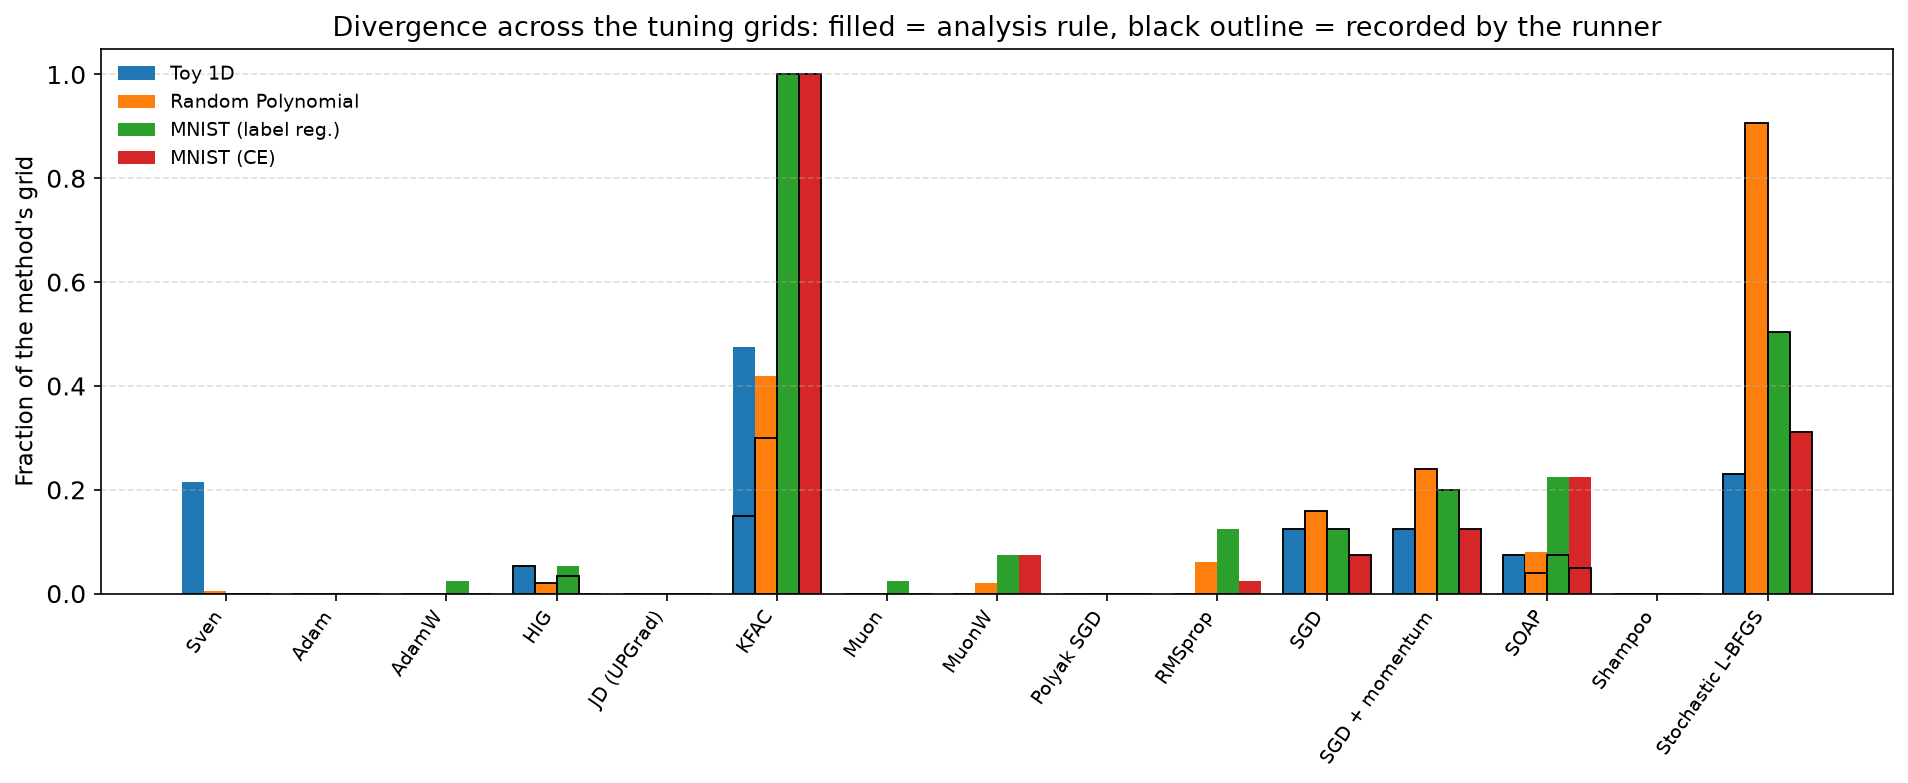

In [18]:
fig, ax = plt.subplots(figsize=(13, 5.5))
m = hf.scan_matrix(div, 'frac_diverged')
rec = hf.scan_matrix(div, 'n_recorded') / hf.scan_matrix(div, 'n_runs')
width = 0.8 / len(m.columns)
x = np.arange(len(m))
for j, c in enumerate(m.columns):
    pos = x + (j - (len(m.columns) - 1) / 2) * width
    ax.bar(pos, m[c], width, label=c)
    ax.bar(pos, rec[c], width, color='none', edgecolor='k', lw=0.9)
ax.set_xticks(x)
ax.set_xticklabels(m.index, rotation=55, ha='right', fontsize=9)
ax.set_ylabel("Fraction of the method's grid", fontsize=11)
ax.set_title('Divergence across the tuning grids: filled = analysis rule, '
             'black outline = recorded by the runner', fontsize=13)
ax.legend(fontsize=9)
ax.grid(axis='y', ls='--', alpha=0.4)
fig.tight_layout()
hf.save(fig, PLOT_DIR, 'divergence_by_method')
plt.show()

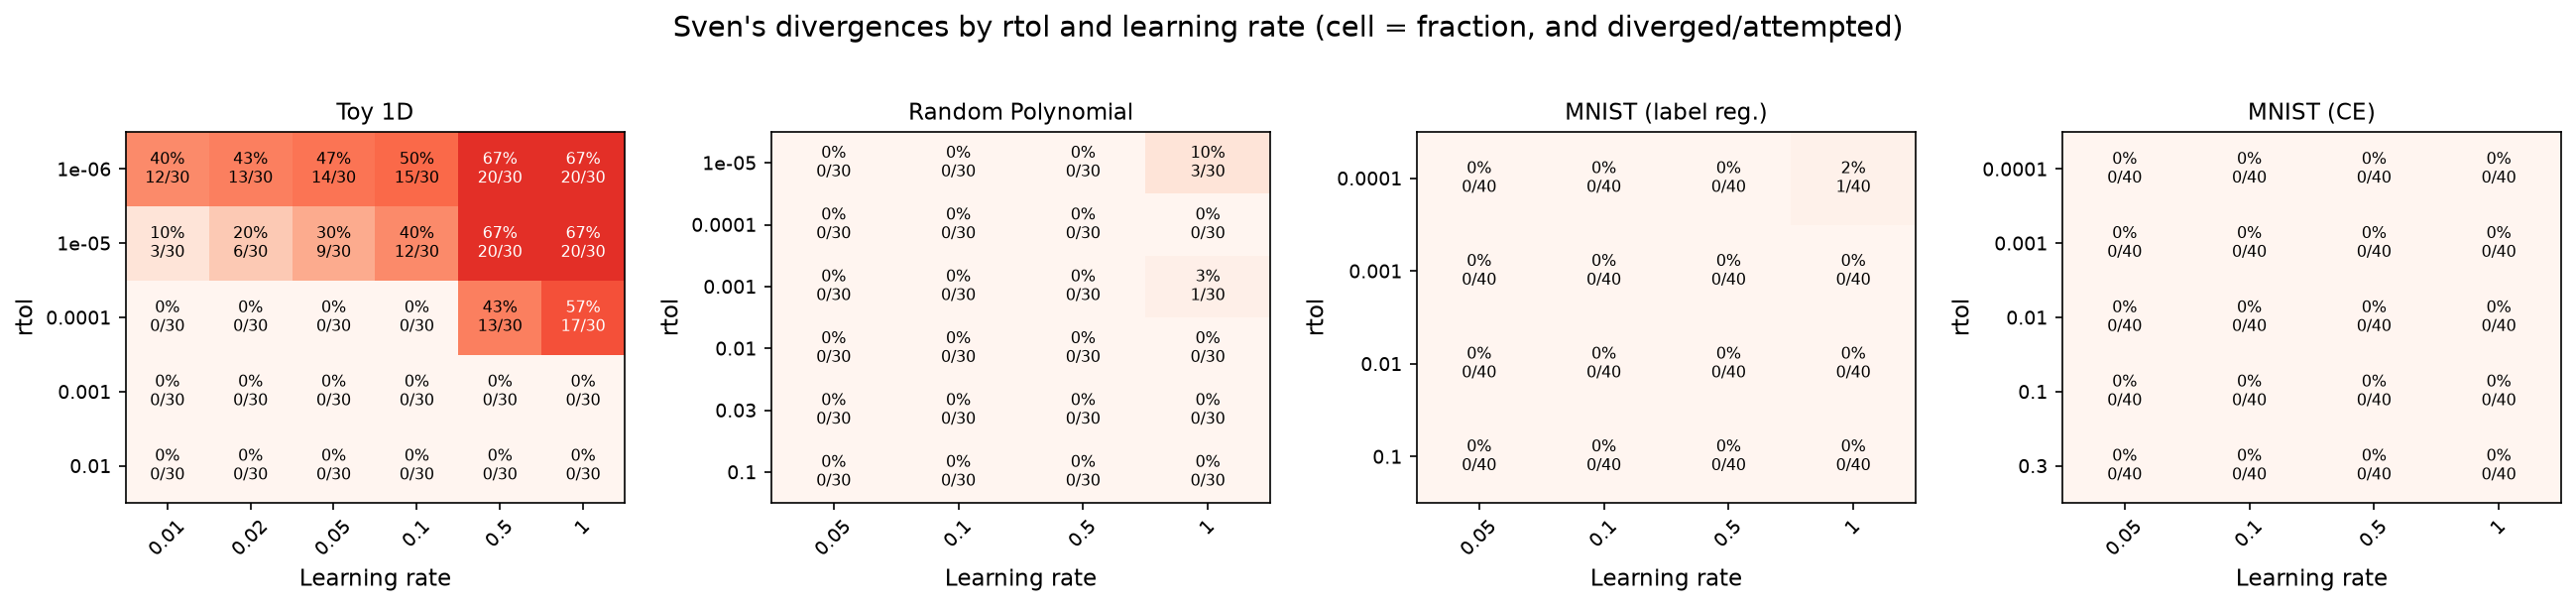

Toy 1D                       194 of 900 Sven runs diverge, at rtol 1e-06, 1e-05, 0.0001 (of 1e-06, 1e-05, 0.0001, 0.001, 0.01) and lr 0.01, 0.02, 0.05, 0.1, 0.5, 1; the fraction rises monotonically with lr
                               worst cell: rtol=1e-06, lr=0.5: 20/30 (67%); confined to the low rtol end: True; rises with lr: True
Random Polynomial            4 of 720 Sven runs diverge, at rtol 1e-05, 0.001 (of 1e-05, 0.0001, 0.001, 0.01, 0.03, 0.1) and lr 1
                               worst cell: rtol=1e-05, lr=1: 3/30 (10%); confined to the low rtol end: False; rises with lr: False
MNIST (label reg.)           1 of 640 Sven runs diverge, at rtol 0.0001 (of 0.0001, 0.001, 0.01, 0.1) and lr 1
                               worst cell: rtol=0.0001, lr=1: 1/40 (2%); confined to the low rtol end: True; rises with lr: False
MNIST (CE)                   NO divergence anywhere on this grid: 0 of 800 Sven runs, at every rtol and every lr


In [19]:
# Where Sven's divergences sit, scan by scan: rtol against learning rate.  Blank = a grid
# point that does not exist.
fig, axes = plt.subplots(1, len(SCANS), figsize=(4.4 * len(SCANS), 4.2), squeeze=False)
for ax, name in zip(axes[0], SCANS):
    frac, counts = hf.sven_divergence_grid(scans[name].df, index='rtol', columns='lr')
    if frac is None:
        ax.axis('off')
        continue
    hf.plot_divergence_grid(frac, ax, counts, ylabel='rtol', xlabel='Learning rate',
                            title=hl.scan_title(name))
    ax.tick_params(labelsize=9); ax.xaxis.label.set_size(11); ax.yaxis.label.set_size(11)
fig.suptitle("Sven's divergences by rtol and learning rate "
             '(cell = fraction, and diverged/attempted)', fontsize=14)
fig.tight_layout()
hf.save(fig, PLOT_DIR, 'sven_divergence_by_scan')
plt.show()

# The verdict per scan, computed from that grid's own counts -- the rtol/lr story is real
# on toy and is NOT a property of the other three.
pattern = {}
for name in SCANS:
    pattern[name] = hf.divergence_pattern(scans[name].df)
    print(f'{hl.scan_title(name):28s} {pattern[name]["summary"]}')
    if pattern[name]['any']:
        print(f'{"":28s}   worst cell: {pattern[name]["worst_cell"]}; '
              f'confined to the low rtol end: '
              f'{pattern[name]["confined_to_low_rtol"]}; rises with lr: '
              f'{pattern[name]["rises_with_lr"]}')

## 8. Sven's selected configuration and the remaining grid edges

One row per scan per axis: the value selected, the grid it was selected from, and whether
it sits in the interior or at an end of that grid.  `k = B` is the uncapped-rank
configuration --- a natural maximum, not an edge that wants extending --- and is labelled
as such.  A real edge means the sweep does not bracket the optimum and the honest statement
is that the best value may lie outside the grid.

In [20]:
rows, sel_all = [], {}
for name in SCANS:
    chosen, entry = hf.selected_sven(name)
    sel_all[name] = chosen
    e = hf.grid_edges(scans[name], chosen)
    e.insert(0, 'scan', hl.scan_title(name))
    rows.append(e)
    print(f'{hl.scan_title(name):28s} B = {scans[name].B:3d}   '
          f'{hl.config_label(entry)}'
          + (f'   -> REMAINING GRID EDGE on {e.attrs["on_edge"]}'
             if e.attrs['on_edge'] else '   -> no remaining grid edge'))
edges = pd.concat(rows, ignore_index=True)
hl.print_table(edges, "Sven's selected configuration against the grid it was selected from")

Toy 1D                       B =  32   k=32, lr=0.01, rtol=0.0001   -> REMAINING GRID EDGE on ['lr']
Random Polynomial            B =  32   k=16, lr=0.5, rtol=0.03   -> no remaining grid edge
MNIST (label reg.)           B =  64   k=64, lr=0.5, rtol=0.001   -> no remaining grid edge
MNIST (CE)                   B =  64   k=32, lr=0.5, rtol=0.3   -> REMAINING GRID EDGE on ['rtol']

### Sven's selected configuration against the grid it was selected from
| scan | axis | selected | n_points | grid | position |
|---|---|---|---|---|---|
| Toy 1D | k | 32 | 6 | 1, 2, 4, 8, 16, 32 | k = B (uncapped rank: a natural maximum, not a grid edge) |
| Toy 1D | lr | 0.01 | 6 | 0.01, 0.02, 0.05, 0.1, 0.5, 1 | LOW EDGE of the grid |
| Toy 1D | rtol | 0.0001 | 5 | 1e-06, 1e-05, 0.0001, 0.001, 0.01 | interior |
| Random Polynomial | k | 16 | 6 | 1, 2, 4, 8, 16, 32 | interior |
| Random Polynomial | lr | 0.5 | 4 | 0.05, 0.1, 0.5, 1 | interior |
| Random Polynomial | rtol | 0.03 | 6 | 1e-05, 0.0001, 0.001, 

,scan,axis,selected,n_points,grid,position
0,Toy 1D,k,32.0000,6,"1, 2, 4, 8, 16, 32","k = B (uncapped rank: a natural maximum, not a..."
1,Toy 1D,lr,0.0100,6,"0.01, 0.02, 0.05, 0.1, 0.5, 1",LOW EDGE of the grid
2,Toy 1D,rtol,0.0001,5,"1e-06, 1e-05, 0.0001, 0.001, 0.01",interior
3,Random Polynomial,k,16.0000,6,"1, 2, 4, 8, 16, 32",interior
4,Random Polynomial,lr,0.5000,4,"0.05, 0.1, 0.5, 1",interior
5,Random Polynomial,rtol,0.0300,6,"1e-05, 0.0001, 0.001, 0.01, 0.03, 0.1",interior
6,MNIST (label reg.),k,64.0000,8,"1, 2, 4, 8, 16, 32, 48, 64","k = B (uncapped rank: a natural maximum, not a..."
7,MNIST (label reg.),lr,0.5000,4,"0.05, 0.1, 0.5, 1",interior
8,MNIST (label reg.),rtol,0.0010,4,"0.0001, 0.001, 0.01, 0.1",interior
9,MNIST (CE),k,32.0000,8,"1, 2, 4, 8, 16, 32, 48, 64",interior


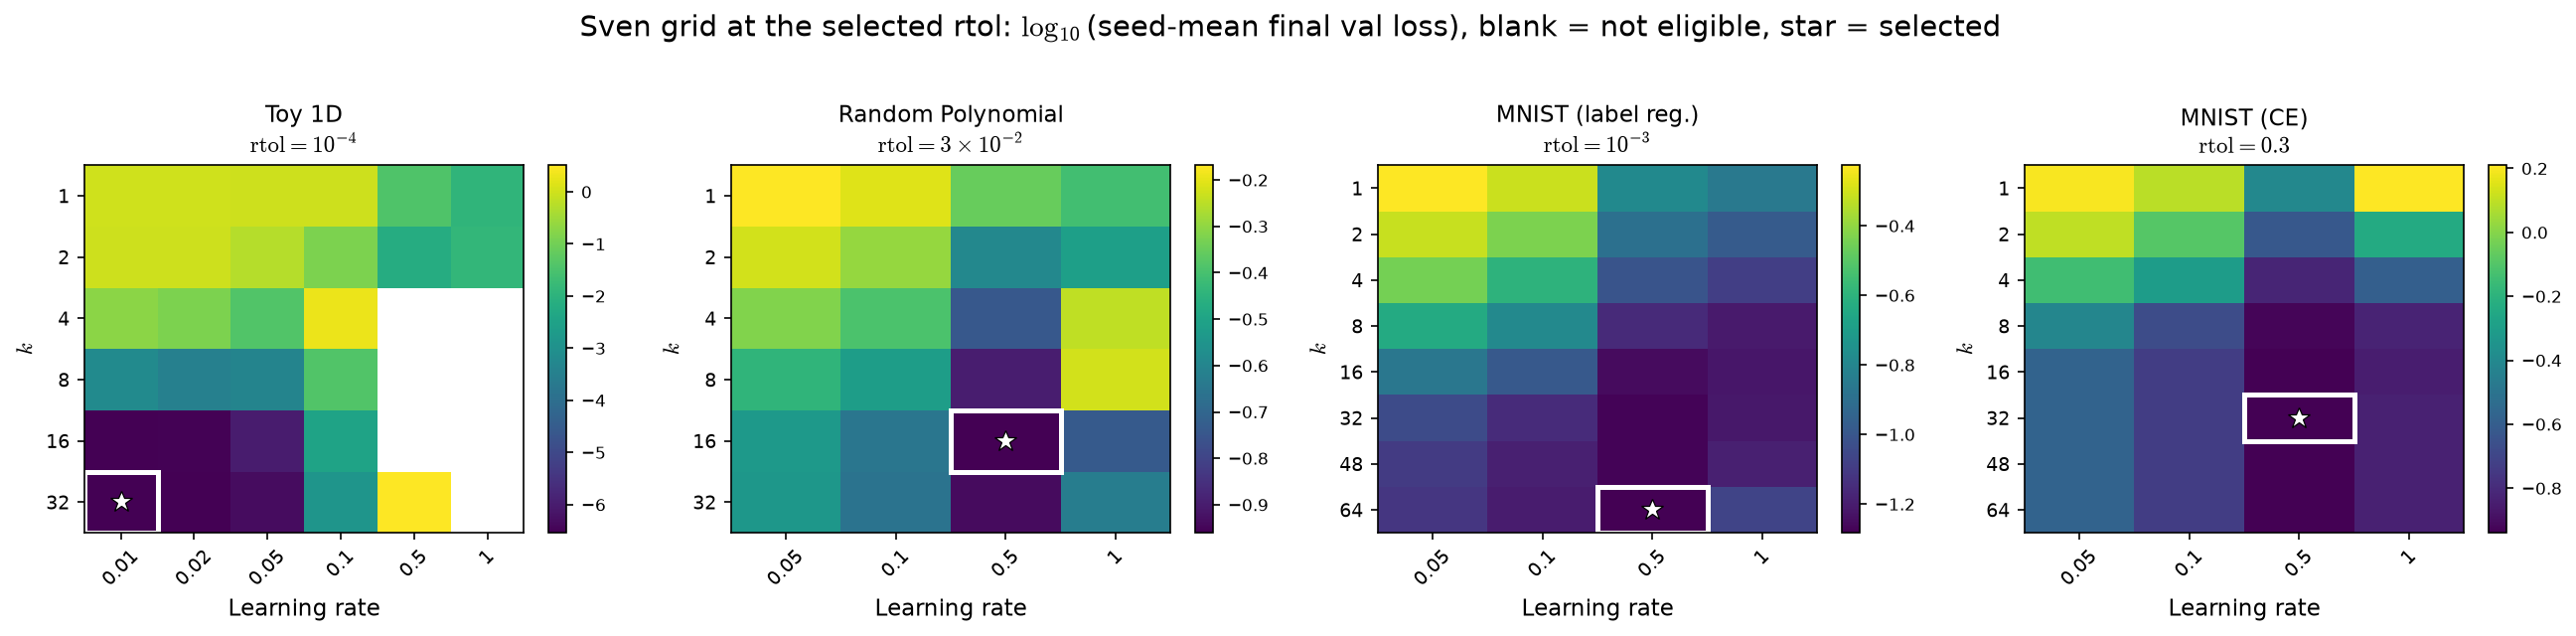

In [21]:
# The landscape itself, one row per scan: log10(seed-mean final val loss) over (k, lr) at
# the SELECTED rtol, with the selected cell ringed.  Blank = not eligible (at most half of
# the seeds finished), so the white regions are section 7 seen from the other side.
fig, axes = plt.subplots(1, len(SCANS), figsize=(4.4 * len(SCANS), 4.4), squeeze=False)
for ax, name in zip(axes[0], SCANS):
    sc = scans[name]
    cfg = hf.sven_grid_table(sc)
    cfg.loc[~cfg['eligible'], 'score'] = np.nan
    piv = (cfg[np.isclose(cfg['rtol'], float(sel_all[name]['rtol']))]
           .pivot_table(values='score', index='k', columns='lr', dropna=False))
    im = ax.imshow(np.log10(piv.values.astype(float)), aspect='auto', cmap='viridis')
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels([f'{c:g}' for c in piv.columns], rotation=45, fontsize=9)
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels([f'{int(i)}' for i in piv.index], fontsize=9)
    ax.set_xlabel('Learning rate', fontsize=11)
    ax.set_ylabel('$k$', fontsize=11)
    ax.set_title(f'{hl.scan_title(name)}\n'
                 f'$\\mathrm{{rtol}} = {sa.fmt(float(sel_all[name]["rtol"]))}$',
                 fontsize=11)
    hf.plot_selected_marker(ax, piv, sel_all[name])
    cb = fig.colorbar(im, ax=ax, fraction=0.046)
    cb.ax.tick_params(labelsize=8)
fig.suptitle('Sven grid at the selected rtol: $\\log_{10}$(seed-mean final val loss), '
             'blank = not eligible, star = selected', fontsize=14)
fig.tight_layout()
hf.save(fig, PLOT_DIR, 'sven_landscape_by_scan')
plt.show()

## 9. Data-seed replicates: how much is the problem, how much is the seed?

Toy and polynomial re-drew the **problem** three times, five model seeds each; MNIST is a
fixed data set and has model seeds only.  `val_conf_dsspread` is the std of the three
per-instance means (how much the answer depends on which problem was drawn) and
`val_conf_seedspread` the seed band averaged over the instances.  Their ratio above 1 means
the draw of the problem moves the answer more than the seed does --- which is also why the
*pooled* selection-optimism gap on those two scans is not selection optimism: it compares
15 runs on 3 problems against 5 tuning runs on 1.


### Toy 1D -- between-instance vs between-seed spread (data seeds [1000, 1001, 1002])
| method | display | n_data_seeds | val_conf | val_conf_dsmean | val_conf_dsspread | val_conf_seedspread | val_conf_ds0 | ratio_instance_over_seed |
|---|---|---|---|---|---|---|---|---|
| HIG | HIG | 3 | 1.775e-09 | 1.775e-09 | 6.388e-10 | 8.081e-10 | 2.352e-09 | 0.7905 |
| Sven | Sven | 3 | 5.086e-07 | 5.086e-07 | 6.449e-07 | 9.449e-07 | 1.051e-07 | 0.6825 |
| SOAP | SOAP | 3 | 3.372e-06 | 3.372e-06 | 9.892e-07 | 3.111e-06 | 3.321e-06 | 0.318 |
| SGDm | SGD + momentum | 3 | 6.027e-06 | 6.027e-06 | 2.064e-06 | 3.166e-06 | 6.945e-06 | 0.652 |
| AdamW | AdamW | 3 | 1.735e-05 | 1.735e-05 | 9.654e-06 | 1.47e-05 | 2.765e-05 | 0.6568 |
| KFAC | KFAC | 3 | 1.802e-05 | 1.802e-05 | 1.296e-05 | 1.477e-05 | 7.953e-06 | 0.8775 |
| MuonW | MuonW | 3 | 1.928e-05 | 1.928e-05 | 1.818e-06 | 9.338e-06 | 1.729e-05 | 0.1947 |
| Muon | Muon | 3 | 2.159e-05 | 2.159e-05 | 8.425e-06 | 1.701e-05 | 3.124e-05 | 0.4953 |
| Ada

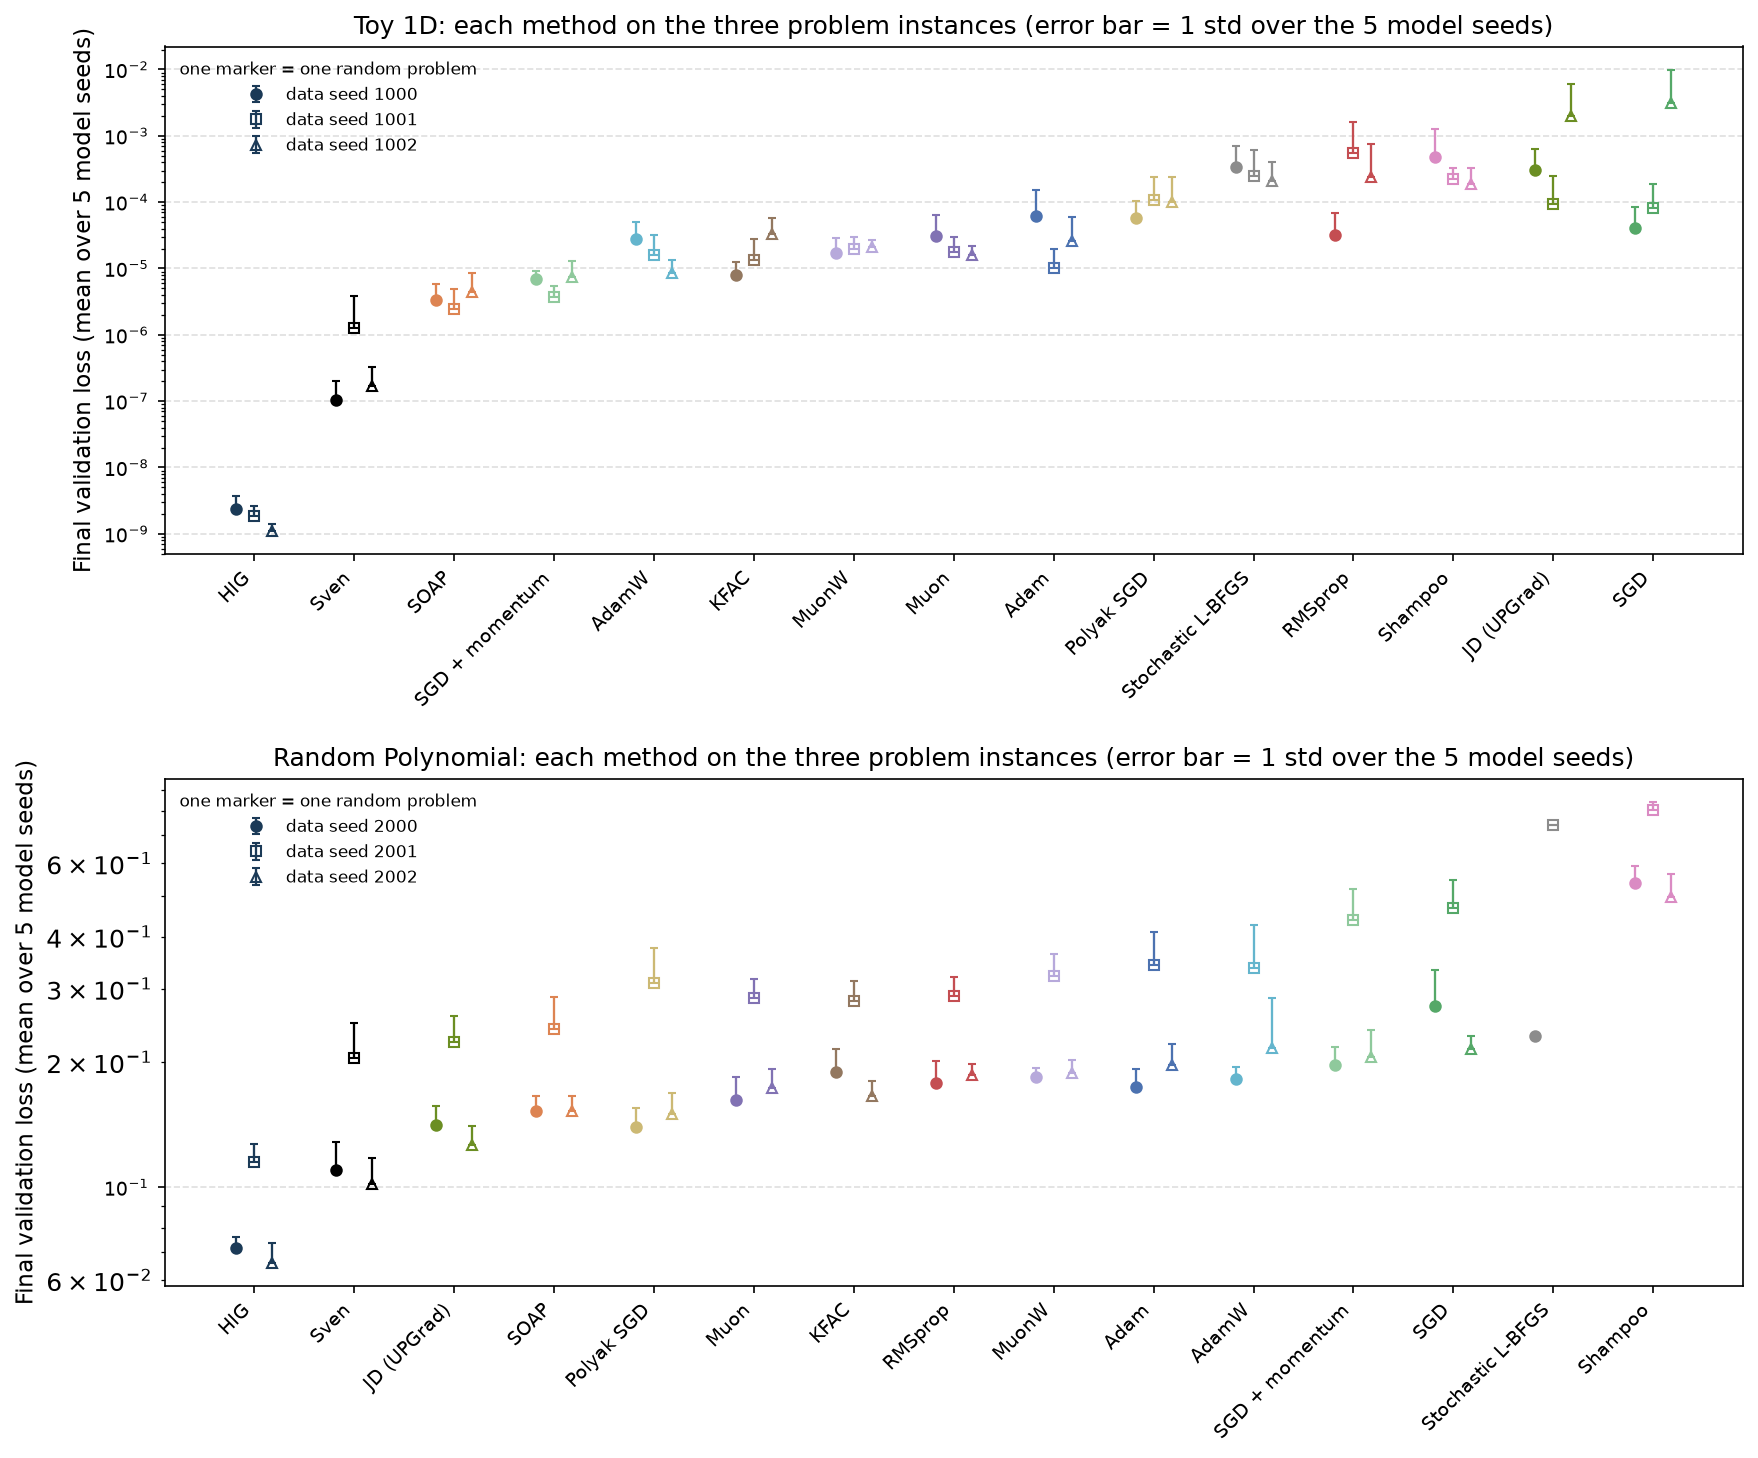

In [22]:
with_seeds = [s for s in SCANS if hl.data_seeds(s)]
spread = {s: hf.instance_spread(s, table=conf[s]) for s in with_seeds}
for s in with_seeds:
    hl.print_table(spread[s], f'{hl.scan_title(s)} -- between-instance vs between-seed '
                              f'spread (data seeds {spread[s].attrs["data_seeds"]})')
    print(f'  median ratio instance/seed: '
          f'{spread[s]["ratio_instance_over_seed"].median(skipna=True):.2f}')
for s in SCANS:
    if s not in with_seeds:
        print(f'{hl.scan_title(s):28s} one fixed problem: no between-instance spread')

fig, axes = plt.subplots(len(with_seeds), 1, figsize=(12, 5 * len(with_seeds)),
                         squeeze=False)
for ax, s in zip(axes[:, 0], with_seeds):
    hf.plot_instance_spread(s, ax, table=conf[s])
    ax.set_title(f'{hl.scan_title(s)}: each method on the three problem instances '
                 f'(error bar = 1 std over the 5 model seeds)', fontsize=12)
    ax.tick_params(labelsize=9); ax.yaxis.label.set_size(11)
fig.tight_layout()
hf.save(fig, PLOT_DIR, 'data_seed_replicates')
plt.show()

## 10. Spectra and mechanism --- pointer

Nothing in this notebook looks at *why*.  The singular-value spectra, the `utr`
diagnostics, the rank actually used against $k$, and the probe-set Jacobian spectra along
the trajectories of Sven and the baselines live in `analysis/spectra_analysis.ipynb` and
`analysis/comparisons.ipynb` (`analysis/ckpt_tools.py`, `analysis/sv_diagnostics.py`), built
from the `{scan}_diag` passes and the cached checkpoint spectra in
`analysis/ckpt_spectra/`.  One number worth carrying across: on the polynomial task the
$k = 16$ truncation discards about **41%** of the residual energy while $k = 32$ keeps
about **74%** --- the truncation is not a formality on these problems.

## 11. What this comparison shows

In [23]:
nums = {}
for name in SCANS:
    nums[name] = hf.closing_numbers(name, conf=conf[name], eff=eff[name], ttt=ttt[name],
                                    budget_tbl=bt[name], div=div[name], paired_tbl=pv[name],
                                    bon=bon_curves[name], df=scans[name].df,
                                    campaign=campaign, verbose=False)
row_keys = ['sven_rank_val', 'n_methods', 'best_method', 'sven_over_best',
            'n_sven_better_sig', 'n_sven_worse_sig', 'n_paired_inconclusive',
            'sven_rank_epochs_to_target', 'n_reached_target',
            'ttt_fewest_epochs_method', 'ttt_fewest_epochs', 'sven_ttt_epochs',
            'sven_slowdown_vs_fastest', 'fastest_method', 'sven_ms_per_step',
            'n_ms_per_step_cheaper_than_sven', 'n_ms_per_step_dearer_than_sven',
            'ms_per_step_just_below_sven', 'ms_per_step_just_above_sven',
            'ms_per_step_dearest',
            'sven_budget_rank_at_equal_n', 'n_methods_at_equal_n',
            'n_better_than_sven_at_equal_n', 'best_at_equal_n',
            'sven_n_to_match_best_at_equal_n',
            'sven_distinct_frac', 'sven_grid_frac', 'sven_grid_recorded',
            'sven_div_pattern', 'worst_method', 'worst_frac', 'sven_gap_rel']
tbl = pd.DataFrame({hl.scan_title(s): {k: nums[s].get(k) for k in row_keys}
                    for s in SCANS}).reindex(row_keys)
hl.print_table(tbl.reset_index().rename(columns={'index': 'quantity'}),
               'The cross-scan summary, computed (nothing below is typed in)')

# Three statements the prose makes, each as a number rather than a claim.
best_sets = {hl.scan_title(s): nums[s]['best_method'] for s in SCANS}
print(f'\nbest method per scan on validation: {best_sets}')
print(f"Sven's rank: " + ', '.join(f"{hl.scan_title(s)} {nums[s]['sven_rank_val']}/"
                                   f"{nums[s]['n_methods']}" for s in SCANS))
print(f"Sven's slowdown vs the fastest method: "
      + ', '.join(f"{hl.scan_title(s)} x{nums[s]['sven_slowdown_vs_fastest']:.2f}"
                  for s in SCANS))
print(f"Sven's grid divergence (analysis rule / recorded): "
      + ', '.join(f"{hl.scan_title(s)} {nums[s]['sven_grid_diverged']}/"
                  f"{nums[s]['sven_grid_runs']} / {nums[s]['sven_grid_recorded']}"
                  for s in SCANS))


### The cross-scan summary, computed (nothing below is typed in)
| quantity | Toy 1D | Random Polynomial | MNIST (label reg.) | MNIST (CE) |
|---|---|---|---|---|
| sven_rank_val | 2 | 2 | 3 | 4 |
| n_methods | 15 | 15 | 14 | 14 |
| best_method | HIG | HIG | MuonW | MuonW |
| sven_over_best | 286.6 | 1.651 | 1.069 | 1.084 |
| n_sven_better_sig | 10 | 12 | 4 | 8 |
| n_sven_worse_sig | 0 | 1 | 1 | 2 |
| n_paired_inconclusive | 4 | 1 | 8 | 3 |
| sven_rank_epochs_to_target | 2 | 4 | 4 | 4 |
| n_reached_target | 13 | 13 | 11 | 11 |
| ttt_fewest_epochs_method | HIG | HIG | Muon | Polyak SGD |
| ttt_fewest_epochs | 2.2 | 3.533 | 6 | 3.6 |
| sven_ttt_epochs | 4.667 | 7.286 | 9.2 | 9.8 |
| sven_slowdown_vs_fastest | 2.56 | 2.529 | 2.811 | 2.915 |
| fastest_method | SGD | SGD + momentum | SGD | SGD |
| sven_ms_per_step | 3.4 | 3.443 | 4.028 | 3.998 |
| n_ms_per_step_cheaper_than_sven | 9 | 10 | 9 | 10 |
| n_ms_per_step_dearer_than_sven | 5 | 4 | 4 | 3 |
| ms_per_step_just_below_sven | SOAP 2.98

*(every number referred to below is printed by the cell above)*

* **Sven is near the front on all four MLP problems but never first.** It is
  `sven_rank_val` of `n_methods` on each, behind **HIG** on the two regression toys and
  behind **MuonW** on both MNIST scans, by a factor `sven_over_best` that shrinks from
  hundreds on the 1-D toy to a few per cent on MNIST. The ranking matrix in section 2 shows
  the same ordering on the test **outcomes**, so nothing here depends on the selection
  split.  The two CIFAR scans, in `cifar_analysis`, are where it drops to the bottom
  third of the field -- section 2's rank matrix carries the current numbers for all seven
  headline scans, and CIFAR-CE is flagged provisional there while its `rtol` extension
  lands, so no rank for it is written into this prose.  The MLP scans are not the whole
  campaign.
* **The paired comparison is stronger than the ranking.** `n_sven_better_sig` of the
  13--14 baselines per scan lose to Sven with a *t*-interval excluding zero,
  `n_sven_worse_sig` beat it, and `n_paired_inconclusive` are inconclusive at five (or
  fifteen) pairs. No *p*-value here is corrected for multiplicity.
* **The axis changes the answer --- and on the epoch axis Sven is near the front, not
  ahead of the field.** To the pre-declared median-method target it is
  `sven_rank_epochs_to_target` of the `n_reached_target` methods that get there at all,
  behind `ttt_fewest_epochs_method` (`ttt_fewest_epochs` epochs against Sven's
  `sven_ttt_epochs`), and the leader is a *different* method on each of the four scans.
  In synchronised training time it costs `sven_slowdown_vs_fastest`x the cheapest method
  (`fastest_method`) per epoch, at `sven_ms_per_step` ms per step ---
  `n_ms_per_step_cheaper_than_sven` selected configurations are cheaper per step and
  `n_ms_per_step_dearer_than_sven` dearer, with `ms_per_step_just_below_sven` and
  `ms_per_step_just_above_sven` its immediate neighbours and `ms_per_step_dearest` the
  dearest. The neighbours differ by scan --- Stochastic L-BFGS is *cheaper* per step than
  Sven on two of the four, and Shampoo and HIG are 18--32x dearer on the two MNIST scans
  but within 20% of Sven on the two regression toys --- so no fixed ordering is quoted; read
  the matrix. Section 6's time-to-target table is the version a practitioner can act on,
  and it counts the methods that never reach the target rather than dropping them.
* **The budget objection is not answered by the distinct-trajectory count, and at a small
  equal budget it goes against Sven.** Sven's grid is the largest in the suite and only
  `sven_distinct_frac` of it is distinct trajectories --- which says the extra points were
  partly redundant, i.e. it is a point *for* the objection.  The equal-budget reading is
  the answer, and it is unflattering: at `n_methods_at_equal_n`-way competition on
  `budget_equal_n` random trials Sven ranks `sven_budget_rank_at_equal_n`, with
  `n_better_than_sven_at_equal_n` method(s) reaching a lower expected best from the same
  number of trials (best: `best_at_equal_n`), and it needs
  `sven_n_to_match_best_at_equal_n` trials to match that --- on the 1-D toy every baseline
  is ahead of it at eight trials and it needs about thirty, on MNIST it never catches the leader at
  any budget its grid allows, and only on the polynomial task is it in the top few at
  equal budget.  Sven's headline standing is a statement about a *well-tuned* Sven, and
  the tuning is part of the cost.
* **Robustness is the honest weak point, and only the wide count shows it.** Sven's grid
  divergence is `sven_grid_frac` under the analysis rule against `sven_grid_recorded` runs
  the runner recorded as diverged --- on `toy_1d_scan` 194 against 0, and campaign-wide
  `campaign_sven_diverged` of `campaign_sven_runs` on-grid runs against
  `campaign_sven_recorded` recorded (`campaign_grids_affected` of `campaign_grids` tuning
  grids affected).  `sven_div_pattern` is the per-scan verdict, computed: the
  rtol-at-the-bottom / worse-with-lr pattern is real on toy (there, only for $k \ge 4$)
  and is **not** a property of the other three, two of which have no Sven divergence at
  all. It is not the worst in the suite --- `worst_method` loses `worst_frac` of its grid,
  and K-FAC loses 40 of 40 runs on both MNIST scans --- but "Sven never diverges" is false
  and toy is where it is false.
* **Selection optimism is small.** `sven_gap_rel` is the tuning-instance gap for Sven; the
  per-method column is in each scan's section 2, and on toy / polynomial the pooled column
  beside it is mostly which random problem was drawn (section 9: the instance spread
  exceeds the seed spread on polynomial).
* **Nothing here is bit-reproducible across GPU types**, and the per-scan notebooks print
  the evidence: the scans ran mostly on A100-40GB MIG slices, the timing and confirmation
  passes partly on full A100-80GB, and only SGD / SGD+momentum reproduce to ~1e-7. Sven
  deviates by 1e-3 to 4e-2 on the two MNIST scans, because its kept rank is chosen by an
  rtol threshold that a 1e-7 kernel difference can flip.  Section 1 prints, per scan,
  whether the **confirmation** pass itself was device-homogeneous: on the two MNIST scans
  it was not (Sven on a full A100-80GB against MuonW and HIG on MIG slices on label
  regression; a 38 / 32 split on cross-entropy), so some of the ranks and paired
  differences above compare methods that ran on different hardware.  `mnist_analysis` and
  `mnist_analysis_labelRegression` print the measured size of that effect next to the
  smallest paired difference they call significant; on MNIST-CE the two are the same order
  of magnitude.  Toy, polynomial and both CIFAR confirmation passes are homogeneous.